Found 50 energy files between 1e+01 and 1e+06 GeV:
  E=1.12202e1 (1.122e+01 GeV)
  E=1.41254e1 (1.413e+01 GeV)
  E=1.77828e1 (1.778e+01 GeV)
  E=2.23872e1 (2.239e+01 GeV)
  E=2.81838e1 (2.818e+01 GeV)
  E=3.54813e1 (3.548e+01 GeV)
  E=4.46684e1 (4.467e+01 GeV)
  E=5.62341e1 (5.623e+01 GeV)
  E=7.07946e1 (7.079e+01 GeV)
  E=8.91251e1 (8.913e+01 GeV)
  E=1.12202e2 (1.122e+02 GeV)
  E=1.41254e2 (1.413e+02 GeV)
  E=1.77828e2 (1.778e+02 GeV)
  E=2.23872e2 (2.239e+02 GeV)
  E=2.81838e2 (2.818e+02 GeV)
  E=3.54813e2 (3.548e+02 GeV)
  E=4.46684e2 (4.467e+02 GeV)
  E=5.62341e2 (5.623e+02 GeV)
  E=7.07946e2 (7.079e+02 GeV)
  E=8.91251e2 (8.913e+02 GeV)
  E=1.12202e3 (1.122e+03 GeV)
  E=1.41254e3 (1.413e+03 GeV)
  E=1.77828e3 (1.778e+03 GeV)
  E=2.23872e3 (2.239e+03 GeV)
  E=2.81838e3 (2.818e+03 GeV)
  E=3.54813e3 (3.548e+03 GeV)
  E=4.46684e3 (4.467e+03 GeV)
  E=5.62341e3 (5.623e+03 GeV)
  E=7.07946e3 (7.079e+03 GeV)
  E=8.91251e3 (8.913e+03 GeV)
  E=1.12202e4 (1.122e+04 GeV)
  E=1.41254e4 (1.41

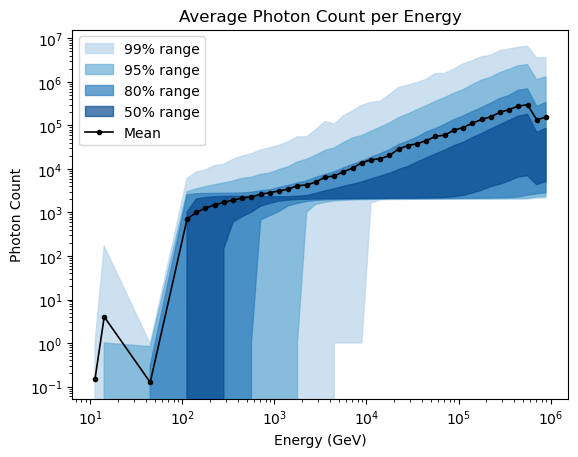

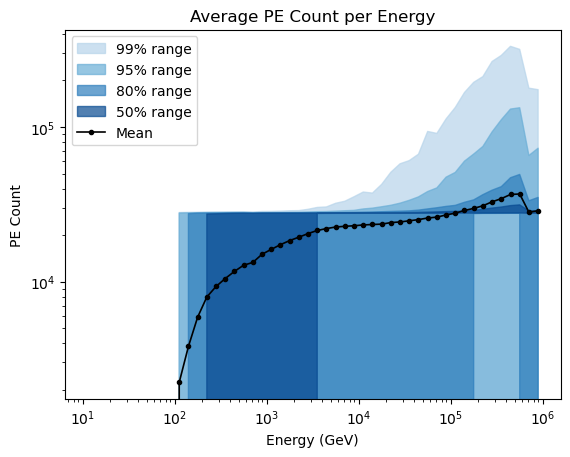

12.880679599761997 TB 4309.33554074138


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import sys
import math

# ── Configuration ─────────────────────────────────────────────────────────────
PE_THRESHOLD = 20
N_BOOTSTRAP = 1000
CI_LEVEL = 0.99
E_MIN_GEV = 1e1
E_MAX_GEV = 1e6
SEEDS = [1,2,3]
PID = 13
RADIUS = 5
BASE_DIR = "/scratch/general/vast/u1520754/muon_sim_chain_tree"


# ── Helper functions ─────────────────────────────────────────────────────────
def load_scan(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    n_missing = (df["file_found"] == 0).sum()
    if n_missing > 0:
        print(f"  WARNING: {n_missing} rows had file_found=0 and will be dropped.")
        index = (df["file_found"] == 0)
        """print("zenith",set(df["zen"][index]))
        print("azimuth",set(df["az"][index]))
        print("height",set(df["height"][index]))"""
    df = df[df["file_found"] == 1].copy()
    df["r"] = np.sqrt(df["tel_x"]**2 + df["tel_z"]**2).round(4)
    df["detected"] = (df["max_pe"] >= PE_THRESHOLD).astype(float)
    return df

def slant_depth(zem, obs_height, zenith_rad):
    theta = np.pi - zenith_rad
    beta = np.clip(np.arcsin((obs_height / zem) * np.sin(theta)), 0, np.pi/2)
    alpha = np.pi - theta - beta
    s = zem * np.sin(alpha) / np.sin(theta)
    return np.clip(s, 0, np.inf)
def incidence_angle(Zenith_deg, Azimuth_deg):
    Zenith = Zenith_deg
    Azimuth = Azimuth_deg
    cos_Zenith = np.cos(np.radians(Zenith))
    cos_Azimuth = np.cos(np.radians(Azimuth - 180))
    cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
    Incidence = np.degrees(np.arccos(cos_Incidence))
    return Incidence
def bootstrap_trigger_rate(max_pe_in_bin, threshold, n_boot=N_BOOTSTRAP):
    alpha_ci = 1.0 - CI_LEVEL
    lo_pct = 100 * alpha_ci / 2
    hi_pct = 100 * (1 - alpha_ci / 2)
    n = len(max_pe_in_bin)
    if n == 0:
        return np.nan, np.nan, np.nan
    observed_rate = np.sum(max_pe_in_bin >= threshold) / n
    boot_rates = np.empty(n_boot)
    for b in range(n_boot):
        sample = np.random.choice(max_pe_in_bin, size=n, replace=True)
        boot_rates[b] = np.sum(sample >= threshold) / n
    ci_low = np.percentile(boot_rates, lo_pct)
    ci_high = np.percentile(boot_rates, hi_pct)
    return observed_rate, ci_low, ci_high

import re
import os

def get_available_energies(base_dir, pid, radius, e_min_GeV, e_max_GeV):
    """
    Scan BASE_DIR for folders matching the given PID and RADIUS,
    extract energy values, and filter by [e_min_GeV, e_max_GeV].
    Returns sorted list of (energy_GeV, energy_str) tuples.
    """
    pattern = re.compile(
        rf"Muon_pid{pid}_E([0-9]+\.?[0-9]*e[+-]?[0-9]+)_R{radius}$"
    )
    found = {}
    for name in os.listdir(base_dir):
        m = pattern.match(name)
        if m:
            energy_str = m.group(1)
            energy_val = float(energy_str)
            if e_min_GeV <= energy_val <= e_max_GeV:
                found[energy_val] = energy_str

    return sorted(found.items())  # sorted by energy_GeV


available = get_available_energies(BASE_DIR, PID, RADIUS, E_MIN_GEV, E_MAX_GEV)
print(f"Found {len(available)} energy files between {E_MIN_GEV:.0e} and {E_MAX_GEV:.0e} GeV:")
for e_val, e_str in available:
    print(f"  E={e_str} ({e_val:.3e} GeV)")

# ── Load only those files ────────────────────────────────────────────────────
dfs = []
missing_energies = []
for energy_val, energy_str in available:
    for seed in SEEDS:
        csv_path = (f"{BASE_DIR}/Muon_pid{PID}_E{energy_str}_R{RADIUS}/"
                    f"csv_output/scan_care_pid{PID}_E{energy_str}_R{RADIUS}_y0_s{seed}.csv")
        try:
            df_tmp = load_scan(csv_path)
            df_tmp["seed"] = seed
            df_tmp["energy_string"] = energy_str
            df_tmp["energy_GeV"] = energy_val
            dfs.append(df_tmp)
            print(f"  Loaded E={energy_str} seed={seed}: {len(df_tmp)} rows")
        except Exception as e:
            missing_energies.append(energy_str)
            print(f"  ⚠ E={energy_str} seed={seed}: {e}")


df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged: {len(df)} total rows from {len(dfs)} file(s)")
print(f"Energy range: {df['energy_GeV'].min():.1f} – {df['energy_GeV'].max():.1f} GeV")
if missing_energies:
    print(f"Missing energies: {sorted(set(missing_energies))}")

# ── Derived columns ──────────────────────────────────────────────────────────
R = np.array(df["r"])
X = np.array(df["tel_x"])
Z = np.array(df["tel_z"])
H = np.array(df["height"])
Zenith = np.array(df["zen"])
Azimuth = np.array(df["az"])
Max_PE = np.array(df["max_pe"])
Time_at_Max_PE = np.array(df["time_at_max_pe_ns"])
Avg_PE = np.array(df["avg_pe"])
Total_PE = np.array(df["total_pe"])
Energy_GeV = np.array(df["energy_GeV"])
Slant = slant_depth(H + 6371e3, 2944 + 6371e3, np.radians(Zenith))/1000 #km
cos_Zenith = np.cos(np.radians(Zenith))
cos_Azimuth = np.cos(np.radians(Azimuth - 180))
cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
Incidence = incidence_angle(Zenith, Azimuth)
#pulse_width = np.array(df["pulse_width_ns"])
#rise_time = np.array(df["rise_time_ns"])
x_mag = np.array(df["correction_x_m"])
y_mag = np.array(df["correction_y_m"])
file_size = np.array(df["file_size_MB"])
photon_count = np.array(df["cph_photon_count"])
max_photon_10ns = np.array(df["cph_max_photons_10ns"])
E_list = np.sort(np.array(list(set(Energy_GeV))))

File = []
Photon = []
PE = []

File_low, File_high = [], []
Photon_low, Photon_high = [], []
PE_low, PE_high = [], []

Total_FIle_Size = np.nansum(file_size)/1000

# --- Coverage levels for nested bands ---
coverages = [50, 80, 95, 99]    # percent
cmap = plt.cm.Blues

# Storage for multi-coverage bands: dict[coverage] -> (lows, highs)
file_bands   = {c: ([], []) for c in coverages}
photon_bands = {c: ([], []) for c in coverages}
pe_bands     = {c: ([], []) for c in coverages}

for energy in E_list:
    mask = Energy_GeV == energy

    f  = np.nanmean(file_size[mask])
    p  = np.nanmean(photon_count[mask])
    pe = np.nanmean(Total_PE[mask])
    File.append(f)
    Photon.append(p)
    PE.append(pe)

    # 99% range (legacy)
    File_low.append(np.nanpercentile(file_size[mask], 0.5))
    File_high.append(np.nanpercentile(file_size[mask], 99.5))
    Photon_low.append(np.nanpercentile(photon_count[mask], 0.5))
    Photon_high.append(np.nanpercentile(photon_count[mask], 99.5))
    PE_low.append(np.nanpercentile(Total_PE[mask], 0.5))
    PE_high.append(np.nanpercentile(Total_PE[mask], 99.5))

    # Multi-coverage percentile bands
    for cov in coverages:
        lo_p = (100 - cov) / 2
        hi_p = 100 - lo_p
        file_bands[cov][0].append(np.nanpercentile(file_size[mask], lo_p))
        file_bands[cov][1].append(np.nanpercentile(file_size[mask], hi_p))
        photon_bands[cov][0].append(np.nanpercentile(photon_count[mask], lo_p))
        photon_bands[cov][1].append(np.nanpercentile(photon_count[mask], hi_p))
        pe_bands[cov][0].append(np.nanpercentile(Total_PE[mask], lo_p))
        pe_bands[cov][1].append(np.nanpercentile(Total_PE[mask], hi_p))

File   = np.array(File)
Photon = np.array(Photon)
PE     = np.array(PE)

File_low, File_high     = np.array(File_low),   np.array(File_high)
Photon_low, Photon_high = np.array(Photon_low), np.array(Photon_high)
PE_low, PE_high         = np.array(PE_low),     np.array(PE_high)

for cov in coverages:
    file_bands[cov]   = (np.array(file_bands[cov][0]),   np.array(file_bands[cov][1]))
    photon_bands[cov] = (np.array(photon_bands[cov][0]), np.array(photon_bands[cov][1]))
    pe_bands[cov]     = (np.array(pe_bands[cov][0]),     np.array(pe_bands[cov][1]))


def plot_with_bands(E_list, mean, bands_dict, coverages, ylabel, title):
    fig, ax = plt.subplots()
    # Widest first (lightest), narrowest last (darkest)
    order = sorted(coverages, reverse=True)
    n = len(order)
    for i, cov in enumerate(order):
        lo, hi = bands_dict[cov]
        color = cmap(0.3 + 0.6 * (i / max(1, n - 1)))
        ax.fill_between(E_list, lo, hi, color=color, alpha=0.7,
                        label=f'{cov}% range')
    ax.plot(E_list, mean, 'k.-', lw=1.2, label='Mean')
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.show()


# --- Photon Count Plot ---
plot_with_bands(E_list, Photon, photon_bands, coverages,
                "Photon Count", "Average Photon Count per Energy")

# --- PE Count Plot ---
plot_with_bands(E_list, PE, pe_bands, coverages,
                "PE Count", "Average PE Count per Energy")

print(Total_FIle_Size/1000, "TB", np.nanmean(Photon)/np.nanmean(File))


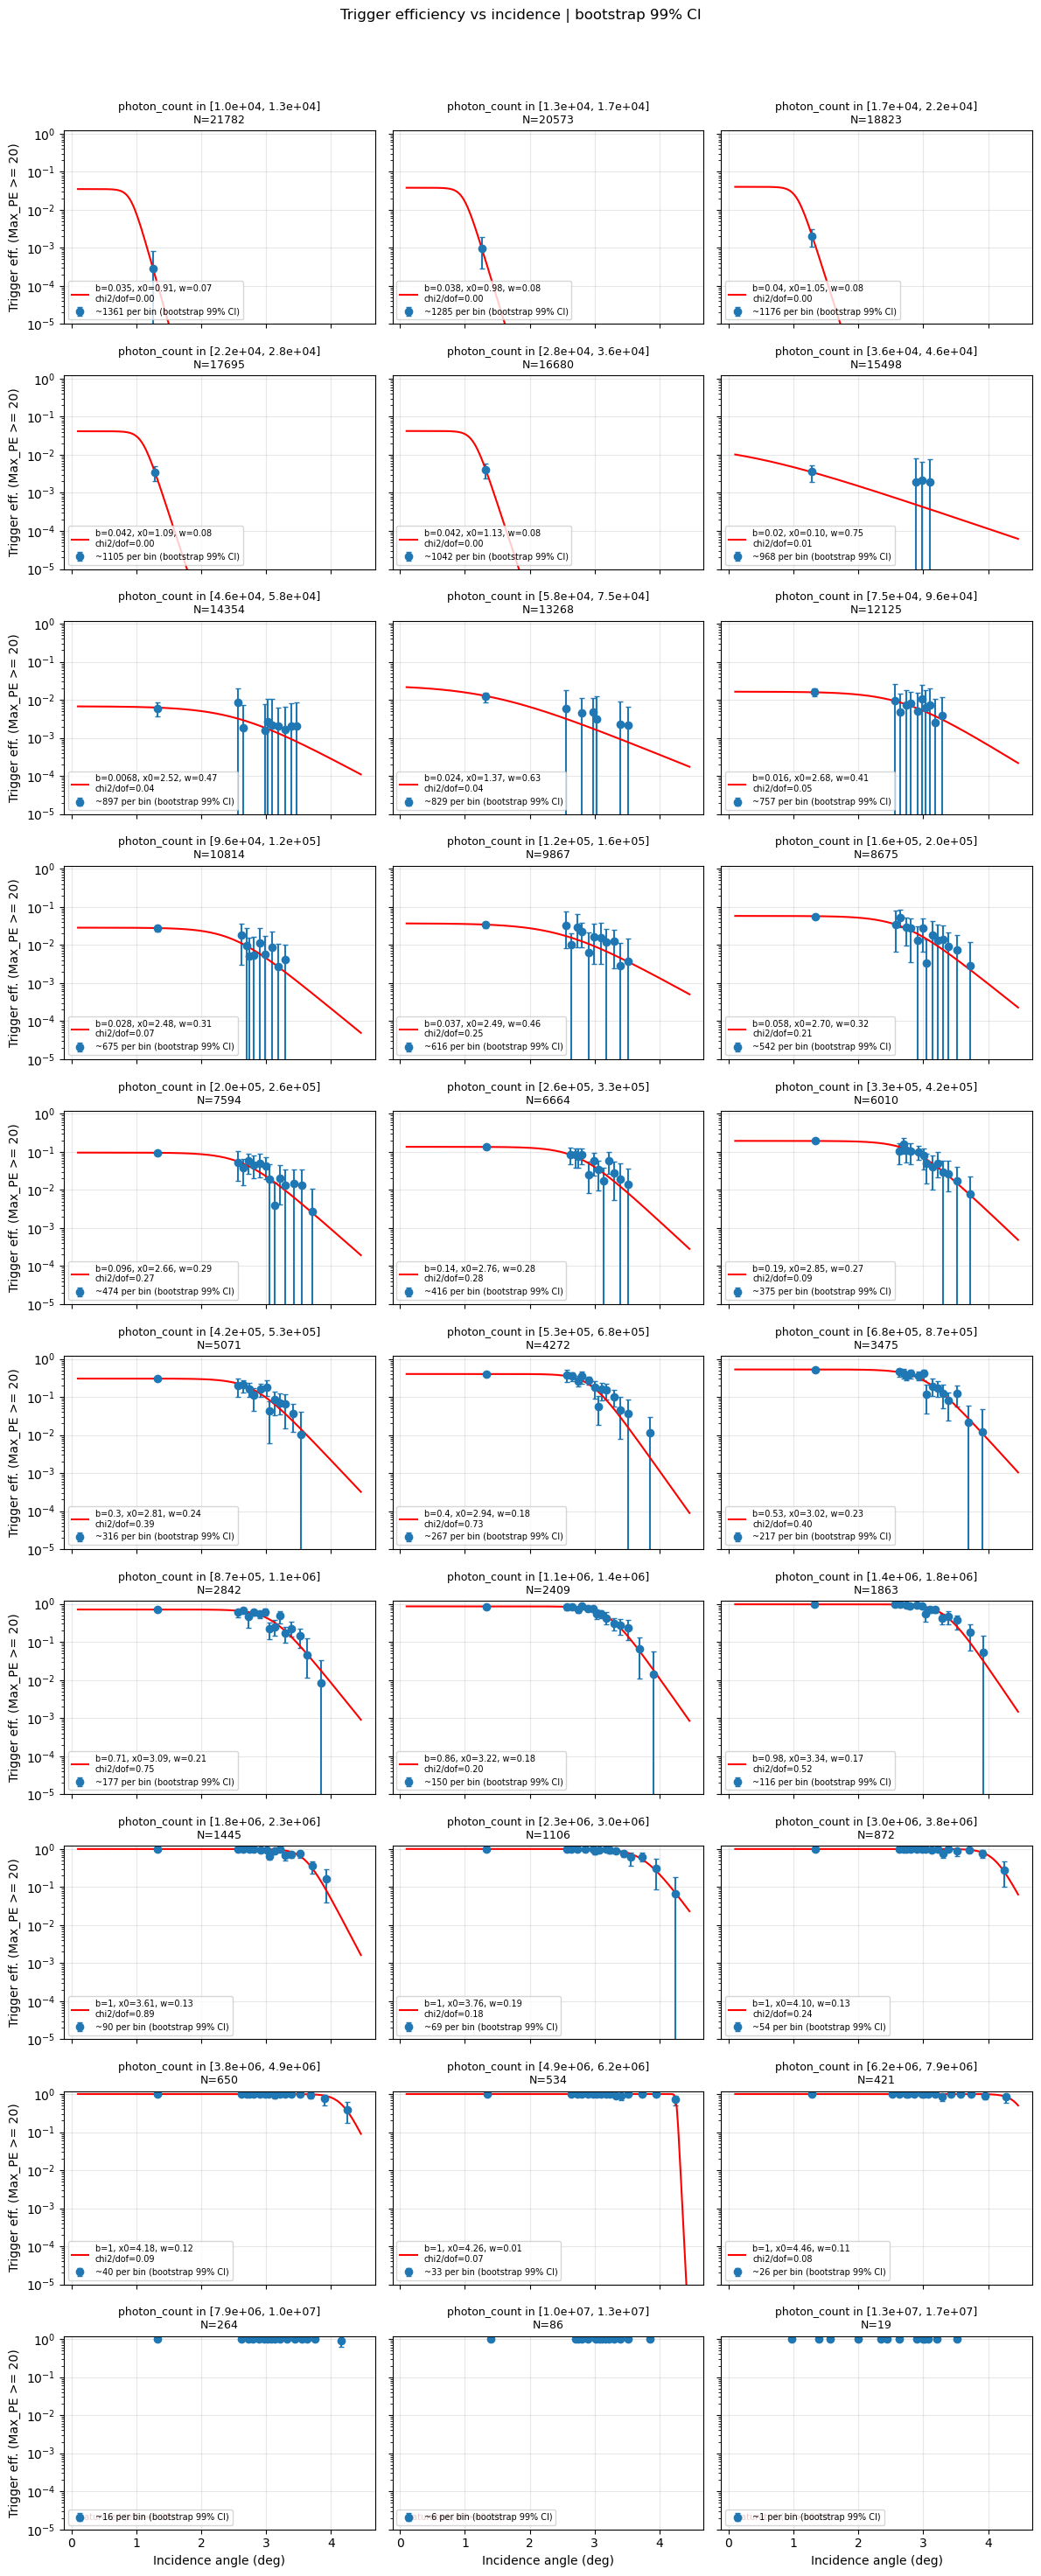

Skipped saturated bins (eff ~ 1 across incidence):
  pc_mean=9.033e+06, N=264
  pc_mean=1.155e+07, N=86
  pc_mean=1.476e+07, N=19
PER-BIN LOGISTIC CUTOFF FIT DIAGNOSTICS
Fit equation: eff(x) = b / (1 + exp((x - x0) / w))
Error bars:   bootstrap 99% CI (N_boot=200)
--------------------------------------------------------------------------------
     pc_mean          b         ±b         x0        ±x0          w         ±w   chi2/dof     minN
--------------------------------------------------------------------------------
   1.195e+04     0.0468    7.1e+11      0.371    5.7e+11      0.035    1.8e+09       0.00     1082
   1.527e+04     0.0362         15      0.100    1.3e+02      0.246        8.2       0.00     1102
   1.952e+04     0.0451        8.6      0.100         74      0.282        5.1       0.02     1028
   2.496e+04     0.0454       0.93      0.100         15      0.468          2       0.01      971
   3.190e+04     0.0606        1.9      0.100         19      0.395          2

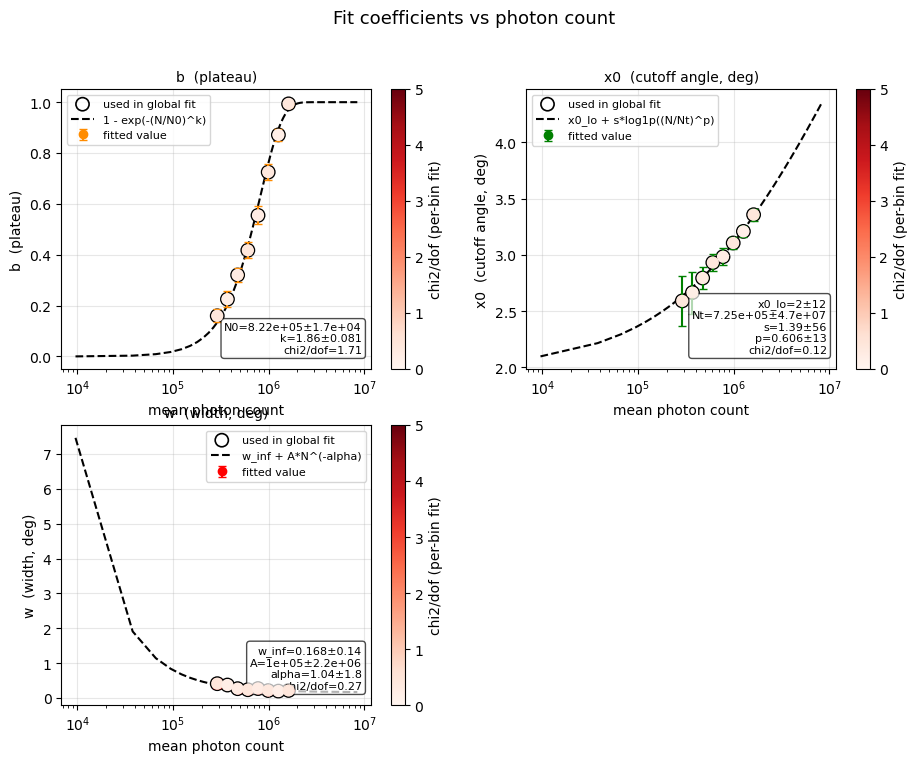


PHYSICAL MODEL FITS (coefficient vs photon count N)

--- Model for parameter 'x0' ---
Equation:  x0(N) = x0_lo + s * log1p((N/Nt)^p)
         x0_lo = 2 ± 12
            Nt = 7.251e+05 ± 4.7e+07
             s = 1.393 ± 56
             p = 0.6057 ± 13
      chi2/dof = 0.121

--- Model for parameter 'b' ---
Equation:  b(N)  = 1 - exp(-(N/N0)^k)
            N0 = 8.222e+05 ± 1.7e+04
             k = 1.865 ± 0.081
      chi2/dof = 1.712

--- Model for parameter 'w' ---
Equation:  w(N)  = w_inf + A * N**(-alpha)
         w_inf = 0.168 ± 0.14
             A = 1e+05 ± 2.2e+06
         alpha = 1.039 ± 1.8
      chi2/dof = 0.273


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize

# --- User settings ---
PE_THRESHOLD = 20
n_photon_bins = 30
n_inc_bins = 15
ncols = 3
BIAS_QUANTILE = 0.5 #bias toward high incidence value
MIN_EVENTS_PER_INC_BIN = 2
MAX_CHI2_DOF = 5.0
MAX_X0_ERR_DEG = 0.5
MAX_W_ERR_DEG = 0.5
EFF_ERR_FLOOR = 0.01
B_ERR_FLOOR = 0.01
W_ERR_FLOOR = 0.01
MIN_PARAM_ERR = 1e-4
SATURATION_EFF = 0.9
B_MIN_SIGNIFICANCE = 0.09
W_MIN_BOUND = 1e-3
B_SATURATION_MAX = 0.999

N_BOOTSTRAP = 200
CI_LEVEL = 99.0  # percent
CI_ALPHA = (100.0 - CI_LEVEL) / 2.0  # 0.5 for 99%

# ---- bootstrap helper ----
def bootstrap_eff_ci(trig_bin, n_boot=N_BOOTSTRAP, ci_alpha=CI_ALPHA):
    """
    trig_bin: 1D array of 0/1 for events in one incidence bin.
    Returns (eff, err_lo, err_hi) where err_lo/hi are half-CI widths
    suitable for asymmetric errorbar.
    """
    n = len(trig_bin)
    if n == 0:
        return np.nan, np.nan, np.nan
    eff = trig_bin.mean()
    boot_effs = np.array([
        np.random.choice(trig_bin, size=n, replace=True).mean()
        for _ in range(n_boot)
    ])
    lo = np.percentile(boot_effs, ci_alpha)
    hi = np.percentile(boot_effs, 100.0 - ci_alpha)
    # symmetric error for fitting: use half-width of CI
    err = (hi - lo) / 2.0
    err = max(err, EFF_ERR_FLOOR)
    return eff, lo, hi, err

# ---- preprocess ----
mask = (
    np.isfinite(photon_count) & (photon_count > 0) &
    np.isfinite(Max_PE) & (Max_PE > 0) &
    np.isfinite(Incidence)
)

pc = photon_count[mask]
inc = Incidence[mask]
pe = Max_PE[mask]
trig = (pe >= PE_THRESHOLD).astype(float)

pc_for_edges = pc[pe >= PE_THRESHOLD]
pc_edges = np.logspace(min(np.log10(pc_for_edges)), max(np.log10(pc_for_edges)),n_photon_bins + 1)#np.unique(np.quantile(pc_for_edges, np.linspace(0, 1, n_photon_bins + 1)))
n_photon_bins = len(pc_edges) - 1

def logistic_cutoff(x, b, x0, w):
    return b / (1.0 + np.exp((x - x0) / w))

# ---- helper: compute bootstrap eff/err arrays for a slice ----
def compute_bootstrap_arrays(inc_slice, trig_slice, inc_edges):
    """
    For each incidence bin defined by inc_edges, bootstrap the efficiency.
    Returns: eff, err_sym, err_lo, err_hi, total arrays (one per bin).
    """
    n_bins = len(inc_edges) - 1
    eff_arr    = np.full(n_bins, np.nan)
    err_arr    = np.full(n_bins, np.nan)
    err_lo_arr = np.full(n_bins, np.nan)
    err_hi_arr = np.full(n_bins, np.nan)
    total_arr  = np.zeros(n_bins, dtype=int)

    for k in range(n_bins):
        in_bin = (inc_slice >= inc_edges[k]) & (inc_slice < inc_edges[k + 1])
        trig_bin = trig_slice[in_bin]
        total_arr[k] = len(trig_bin)
        if len(trig_bin) == 0:
            continue
        eff, lo, hi, err = bootstrap_eff_ci(trig_bin)
        eff_arr[k]    = eff
        err_lo_arr[k] = eff - lo   # distance below
        err_hi_arr[k] = hi - eff   # distance above
        err_arr[k]    = err

    return eff_arr, err_arr, err_lo_arr, err_hi_arr, total_arr

# ======================================================================
# PLOT: trigger efficiency per photon-count bin
# ======================================================================
nrows = int(np.ceil(n_photon_bins / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True
)
axes = np.atleast_1d(axes).ravel()
x_fit = np.linspace(inc.min(), inc.max(), 200)

for i in range(n_photon_bins):
    ax = axes[i]
    pc_lo, pc_hi = pc_edges[i], pc_edges[i + 1]
    sub = (pc >= pc_lo) & (pc < pc_hi)
    n_sub = sub.sum()

    if n_sub == 0:
        ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN=0")
        continue

    inc_sub = inc[sub]
    trig_sub = trig[sub]

    inc_threshold = np.quantile(inc_sub, BIAS_QUANTILE)
    inc_upper = inc_sub[inc_sub >= inc_threshold]
    if len(inc_upper) >= n_inc_bins:
        inc_edges_upper = np.unique(
            np.quantile(inc_upper, np.linspace(0, 1, n_inc_bins + 1))
        )
        inc_edges = np.unique(np.concatenate([[inc_sub.min()], inc_edges_upper]))
    else:
        inc_edges = np.unique(
            np.quantile(inc_sub, np.linspace(0, 1, n_inc_bins + 1))
        )

    if len(inc_edges) < 3:
        ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN={n_sub}")
        ax.text(0.5, 0.5, "insufficient bins", transform=ax.transAxes,
                ha='center', va='center', fontsize=8, color='red')
        continue

    n_bins_actual = len(inc_edges) - 1
    inc_centers = 0.5 * (inc_edges[:-1] + inc_edges[1:])

    eff, err, err_lo, err_hi, total = compute_bootstrap_arrays(
        inc_sub, trig_sub, inc_edges
    )

    # asymmetric error bars from bootstrap CI
    yerr_asym = np.array([
        np.where(np.isfinite(err_lo), err_lo, 0),
        np.where(np.isfinite(err_hi), err_hi, 0)
    ])

    ax.errorbar(inc_centers, eff, yerr=yerr_asym, fmt='o', capsize=2,
                label=f"~{n_sub // n_bins_actual} per bin (bootstrap {CI_LEVEL:.0f}% CI)")

    eff_valid = eff[np.isfinite(eff)]
    saturated = bool(eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF))

    good = np.isfinite(eff) & (total > 0)
    min_total = int(np.min(total[total > 0])) if np.any(total > 0) else 0

    if saturated:
        ax.text(0.05, 0.05, f"saturated (eff>={SATURATION_EFF:.2f})",
                transform=ax.transAxes, fontsize=7, color='darkred')
    elif good.sum() >= 4 and min_total >= MIN_EVENTS_PER_INC_BIN:
        xd = inc_centers[good]
        yd = eff[good]
        sd = np.where(err[good] > 0, err[good], EFF_ERR_FLOOR)

        inc_range = inc_edges[-1] - inc_edges[0]
        b0 = min(max(np.nanmax(yd), 0.05), 1.0)
        x0_0 = xd[np.argmin(np.abs(yd - 0.5 * np.nanmax(yd)))]
        w0 = max(0.02 * (inc_range + 1e-6), 1e-3)
        p0 = [b0, x0_0, w0]
        bounds = (
            [0.0, inc_edges[0], 1e-3],
            [1.05, inc_edges[-1], 0.4 * inc_range],
        )

        try:
            popt, _ = curve_fit(
                logistic_cutoff, xd, yd, p0=p0, sigma=sd,
                absolute_sigma=True, bounds=bounds, maxfev=20000
            )
            y_model = logistic_cutoff(xd, *popt)
            chi2 = np.sum(((yd - y_model) / sd) ** 2)
            dof = len(xd) - 3
            chi2_dof = chi2 / dof if dof > 0 else np.nan

            ax.plot(x_fit, logistic_cutoff(x_fit, *popt), 'r-', lw=1.5,
                    label=(f"b={popt[0]:.2g}, x0={popt[1]:.2f}, "
                           f"w={popt[2]:.2f}\nchi2/dof={chi2_dof:.2f}"))
        except Exception:
            ax.text(0.05, 0.05, "fit failed", transform=ax.transAxes,
                    fontsize=8, color='red')
    else:
        ax.text(0.05, 0.05, f"low stats (min N={min_total})",
                transform=ax.transAxes, fontsize=7, color='darkred')

    ax.legend(fontsize=7, loc='lower left')
    ax.set_ylim(1e-5, 1.2)
    ax.set_yscale("log")
    ax.set_title(f"photon_count in [{pc_lo:.1e}, {pc_hi:.1e}]\nN={n_sub}", fontsize=9)
    ax.grid(alpha=0.3)

for j in range(n_photon_bins, len(axes)):
    axes[j].set_visible(False)

for ax in axes[:n_photon_bins]:
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel("Incidence angle (deg)")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")

fig.suptitle(f"Trigger efficiency vs incidence | bootstrap {CI_LEVEL:.0f}% CI", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ======================================================================
# PER-BIN FIT LOOP
# ======================================================================
pc_means, x0_vals, x0_errs = [], [], []
b_vals, b_errs = [], []
w_vals, w_errs = [], []
chi2_vals = []
min_counts = []
mean_counts = []
saturated_bins = []
saturated_ranges = []

for i in range(n_photon_bins):
    pc_lo, pc_hi = pc_edges[i], pc_edges[i + 1]
    sub = (pc >= pc_lo) & (pc < pc_hi)
    if sub.sum() == 0:
        continue

    inc_sub = inc[sub]
    trig_sub = trig[sub]

    inc_edges = np.unique(
        np.quantile(inc_sub, np.linspace(0, 1, n_inc_bins + 1))
    )
    if len(inc_edges) < 3:
        continue

    inc_centers = 0.5 * (inc_edges[:-1] + inc_edges[1:])
    inc_range = inc_edges[-1] - inc_edges[0]

    eff, err, err_lo, err_hi, total = compute_bootstrap_arrays(
        inc_sub, trig_sub, inc_edges
    )

    eff_valid = eff[np.isfinite(eff)]
    if eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF):
        saturated_bins.append((0.5 * (pc_lo + pc_hi), int(sub.sum())))
        saturated_ranges.append((pc_lo, pc_hi))
        continue

    good = np.isfinite(eff) & (total > 0)
    if good.sum() < 4:
        continue

    xd = inc_centers[good]
    yd = eff[good]
    sd = np.where(err[good] > 0, err[good], EFF_ERR_FLOOR)

    min_total = int(np.min(total[total > 0])) if np.any(total > 0) else 0
    mean_total = float(np.mean(total[total > 0])) if np.any(total > 0) else 0.0

    b0 = min(max(np.nanmax(yd), 0.05), 1.0)
    x0_0 = xd[np.argmin(np.abs(yd - 0.5 * np.nanmax(yd)))]
    w0 = max(0.02 * (inc_range + 1e-6), 1e-3)
    p0 = [b0, x0_0, w0]
    bounds = (
        [0.0, inc_edges[0], 1e-3],
        [1.05, inc_edges[-1], 0.4 * inc_range],
    )

    try:
        popt, pcov = curve_fit(
            logistic_cutoff, xd, yd, p0=p0, sigma=sd,
            absolute_sigma=True, bounds=bounds, maxfev=20000
        )
        perr = np.sqrt(np.diag(pcov))
        y_model = logistic_cutoff(xd, *popt)
        chi2 = np.sum(((yd - y_model) / sd) ** 2)
        dof = len(xd) - 3
        chi2_dof = chi2 / dof if dof > 0 else np.nan

        pc_means.append(0.5 * (pc_lo + pc_hi))
        b_vals.append(popt[0]);  b_errs.append(perr[0])
        x0_vals.append(popt[1]); x0_errs.append(perr[1])
        w_vals.append(popt[2]);  w_errs.append(perr[2])
        chi2_vals.append(chi2_dof)
        min_counts.append(min_total)
        mean_counts.append(mean_total)

    except Exception:
        continue

if saturated_bins:
    print("Skipped saturated bins (eff ~ 1 across incidence):")
    for pc_mean, n_sub in saturated_bins:
        print(f"  pc_mean={pc_mean:.3e}, N={n_sub}")

pc_means   = np.array(pc_means)
b_vals,  b_errs  = np.array(b_vals),  np.array(b_errs)
x0_vals, x0_errs = np.array(x0_vals), np.array(x0_errs)
w_vals,  w_errs  = np.array(w_vals),  np.array(w_errs)
chi2_vals  = np.array(chi2_vals)
min_counts = np.array(min_counts)
mean_counts = np.array(mean_counts)

# -- quality mask --
cutoff_in_range = (
    (x0_vals + 2.0 * w_vals <= inc.max()) &
    (x0_vals - 2.0 * w_vals >= inc.min())
)
finite_mask = (
    np.isfinite(chi2_vals) & np.isfinite(x0_errs) &
    np.isfinite(w_errs) & np.isfinite(b_errs)
)
stats_mask = min_counts >= MIN_EVENTS_PER_INC_BIN
err_mask = (
    (x0_errs < MAX_X0_ERR_DEG) & (w_errs < MAX_W_ERR_DEG) &
    (b_errs > MIN_PARAM_ERR) & (x0_errs > MIN_PARAM_ERR) & (w_errs > MIN_PARAM_ERR)
)
chi2_mask = chi2_vals < MAX_CHI2_DOF

with np.errstate(divide='ignore', invalid='ignore'):
    b_signif = np.where(b_errs > 0, b_vals / b_errs, 0.0)
b_signif_mask = b_signif >= B_MIN_SIGNIFICANCE

w_bound_mask = w_vals > W_MIN_BOUND * 1.05
b_saturation_mask = b_vals < B_SATURATION_MAX

quality_mask = (
    finite_mask & stats_mask & err_mask &
    chi2_mask & cutoff_in_range & b_signif_mask &
    w_bound_mask & b_saturation_mask
)

# -- diagnostics print --
print("=" * 80)
print("PER-BIN LOGISTIC CUTOFF FIT DIAGNOSTICS")
print("=" * 80)
print("Fit equation: eff(x) = b / (1 + exp((x - x0) / w))")
print(f"Error bars:   bootstrap {CI_LEVEL:.0f}% CI (N_boot={N_BOOTSTRAP})")
print("-" * 80)
print(f"{'pc_mean':>12} {'b':>10} {'±b':>10} {'x0':>10} {'±x0':>10} "
      f"{'w':>10} {'±w':>10} {'chi2/dof':>10} {'minN':>8}")
print("-" * 80)
for i in range(len(pc_means)):
    print(f"{pc_means[i]:12.3e} "
          f"{b_vals[i]:10.3g} {b_errs[i]:10.2g} "
          f"{x0_vals[i]:10.3f} {x0_errs[i]:10.2g} "
          f"{w_vals[i]:10.3f} {w_errs[i]:10.2g} "
          f"{chi2_vals[i]:10.2f} {min_counts[i]:8d}")
print("-" * 80)
print(f"Bins fitted: {len(pc_means)} | Bins used for global fits: {int(np.sum(quality_mask))}")
print("=" * 80)

dropped = ~quality_mask
if np.any(dropped):
    print("\nBins EXCLUDED from global fits:")
    print(f"{'pc_mean':>12} {'b/σ_b':>8} {'chi2/dof':>10} {'minN':>8}  reasons")
    for i in np.where(dropped)[0]:
        reasons = []
        if not finite_mask[i]:     reasons.append("nonfinite")
        if not stats_mask[i]:      reasons.append(f"minN<{MIN_EVENTS_PER_INC_BIN}")
        if not err_mask[i]:        reasons.append("err-cut")
        if not chi2_mask[i]:       reasons.append(f"chi2>{MAX_CHI2_DOF}")
        if not cutoff_in_range[i]: reasons.append("x0 out of range")
        if not b_signif_mask[i]:   reasons.append(f"b/σ_b<{B_MIN_SIGNIFICANCE}")
        if not b_saturation_mask[i]: reasons.append(f"b>={B_SATURATION_MAX}")
        if not w_bound_mask[i]:      reasons.append(f"w<={W_MIN_BOUND:g}")
        bs = b_signif[i] if np.isfinite(b_signif[i]) else 0.0
        print(f"{pc_means[i]:12.3e} {bs:8.2f} {chi2_vals[i]:10.2f} "
              f"{min_counts[i]:8d}  " + ", ".join(reasons))

# -- physical models --
def x0_softplus(N, x0_lo, Nt, s, p):
    N = np.maximum(N, 1e-12)
    Nt = np.maximum(Nt, 1e-12)
    return x0_lo + s * np.log1p((N / Nt) ** p)

def plateau_model(N, N0, k):
    N = np.maximum(N, 1e-12)
    return 1.0 - np.exp(-(N / N0) ** k)

def w_model(N, w_inf, A, alpha):
    N = np.maximum(N, 1e-12)
    return w_inf + A * N**(-alpha)

results = {}

def fit_model(fn, xdata, ydata, yerr, p0, bounds):
    sigma = np.where(yerr > 0, yerr, EFF_ERR_FLOOR)
    popt, pcov = curve_fit(
        fn, xdata, ydata, p0=p0, sigma=sigma,
        absolute_sigma=True, bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    residuals = ydata - fn(xdata, *popt)
    chi2 = np.sum((residuals / sigma) ** 2)
    dof = len(xdata) - len(popt)
    chi2_dof = chi2 / dof if dof > 0 else np.nan
    return popt, perr, pcov, chi2_dof

ok_x0 = quality_mask & np.isfinite(x0_errs)
try:
    popt, perr, pcov, c2 = fit_model(
        x0_softplus, pc_means[ok_x0], x0_vals[ok_x0],
        np.maximum(x0_errs[ok_x0], W_ERR_FLOOR),
        p0=[3.0, 1e6, 0.5, 2.0],
        bounds=([2.0, 1e5, 0.0, 0.5], [5.0, 1e7, 5.0, 10.0])
    )
    results['x0'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"x0 model fit failed: {e}")

ok_b = quality_mask & (b_vals < B_SATURATION_MAX) & np.isfinite(b_errs)
try:
    popt, perr, pcov, c2 = fit_model(
        plateau_model, pc_means[ok_b], b_vals[ok_b],
        np.maximum(b_errs[ok_b], B_ERR_FLOOR),
        p0=[np.median(pc_means[ok_b]), 1.0],
        bounds=([pc_means.min() * 0.1, 0.1], [pc_means.max() * 10.0, 10.0])
    )
    results['b'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"b model fit failed: {e}")

ok_w = quality_mask & np.isfinite(w_errs) & (w_vals > 0)
try:
    popt, perr, pcov, c2 = fit_model(
        w_model, pc_means[ok_w], w_vals[ok_w],
        np.maximum(w_errs[ok_w], W_ERR_FLOOR),
        p0=[0.15, 50.0, 0.5],
        bounds=([0.0, 0.0, 0.1], [1.0, 1e5, 1.5])
    )
    results['w'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"w model fit failed: {e}")

# -- comparison plot --
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
N_smooth = np.linspace(pc_means.min() * 0.8, pc_means.max() * 1.2, 300)

labels      = ['b  (plateau)', 'x0  (cutoff angle, deg)', 'w  (width, deg)']
yvals       = [b_vals, x0_vals, w_vals]
yerrs       = [b_errs, x0_errs, w_errs]
colors      = ['darkorange', 'green', 'red']
model_keys  = ['b', 'x0', 'w']
model_fns   = [plateau_model, x0_softplus, w_model]
model_labels = {
    'x0': r"x0_lo + s*log1p((N/Nt)^p)",
    'b':  r"1 - exp(-(N/N0)^k)",
    'w':  r"w_inf + A*N^(-alpha)",
}
param_names = {
    'x0': ['x0_lo', 'Nt', 's', 'p'],
    'b':  ['N0', 'k'],
    'w':  ['w_inf', 'A', 'alpha'],
}

for ax, lbl, yv, ye, col, mkey, mfn in zip(
        axes[:len(labels)], labels, yvals, yerrs, colors, model_keys, model_fns):

    qm = quality_mask
    ax.errorbar(pc_means[qm], yv[qm], yerr=ye[qm], fmt='o', color=col,
                capsize=3, label='fitted value', zorder=3)
    sc = ax.scatter(pc_means[qm], yv[qm], c=chi2_vals[qm], cmap='Reds',
                    vmin=0, vmax=5, zorder=5, s=60)
    plt.colorbar(sc, ax=ax, label='chi2/dof (per-bin fit)')
    ax.scatter(pc_means[qm], yv[qm],
               facecolors='none', edgecolors='black', s=90,
               linewidths=1.2, label='used in global fit')

    if mkey in results:
        popt, perr, pcov, c2 = results[mkey]
        ax.plot(N_smooth, mfn(N_smooth, *popt), 'k--',
                lw=1.5, label=model_labels[mkey])
        txt = "\n".join(f"{n}={v:.3g}±{e:.2g}"
                        for n, v, e in zip(param_names[mkey], popt, perr))
        txt += f"\nchi2/dof={c2:.2f}"
        ax.text(0.97, 0.05, txt, transform=ax.transAxes, fontsize=8,
                ha='right', va='bottom',
                bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    ax.set_xscale('log')
    ax.set_xlabel('mean photon count')
    ax.set_ylabel(lbl)
    ax.set_title(lbl, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[len(labels):]:
    ax.axis('off')

fig.suptitle("Fit coefficients vs photon count", fontsize=13)
#fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# -- physical model summary --
print("\n" + "=" * 80)
print("PHYSICAL MODEL FITS (coefficient vs photon count N)")
print("=" * 80)
model_equations = {
    'x0': "x0(N) = x0_lo + s * log1p((N/Nt)^p)",
    'b':  "b(N)  = 1 - exp(-(N/N0)^k)",
    'w':  "w(N)  = w_inf + A * N**(-alpha)",
}
for key in ['x0', 'b', 'w']:
    print(f"\n--- Model for parameter '{key}' ---")
    print(f"Equation:  {model_equations[key]}")
    if key in results:
        popt, perr, pcov, c2 = results[key]
        for name, val, err in zip(param_names[key], popt, perr):
            print(f"  {name:>12} = {val:.4g} ± {err:.2g}")
        print(f"  {'chi2/dof':>12} = {c2:.3f}")
    else:
        print("  FIT FAILED or not available")
print("=" * 80)


/tmp/ipykernel_156712/3891591356.py:75: RuntimeWarning: overflow encountered in exp
  return b / (1.0 + np.exp((x - x0) / w))


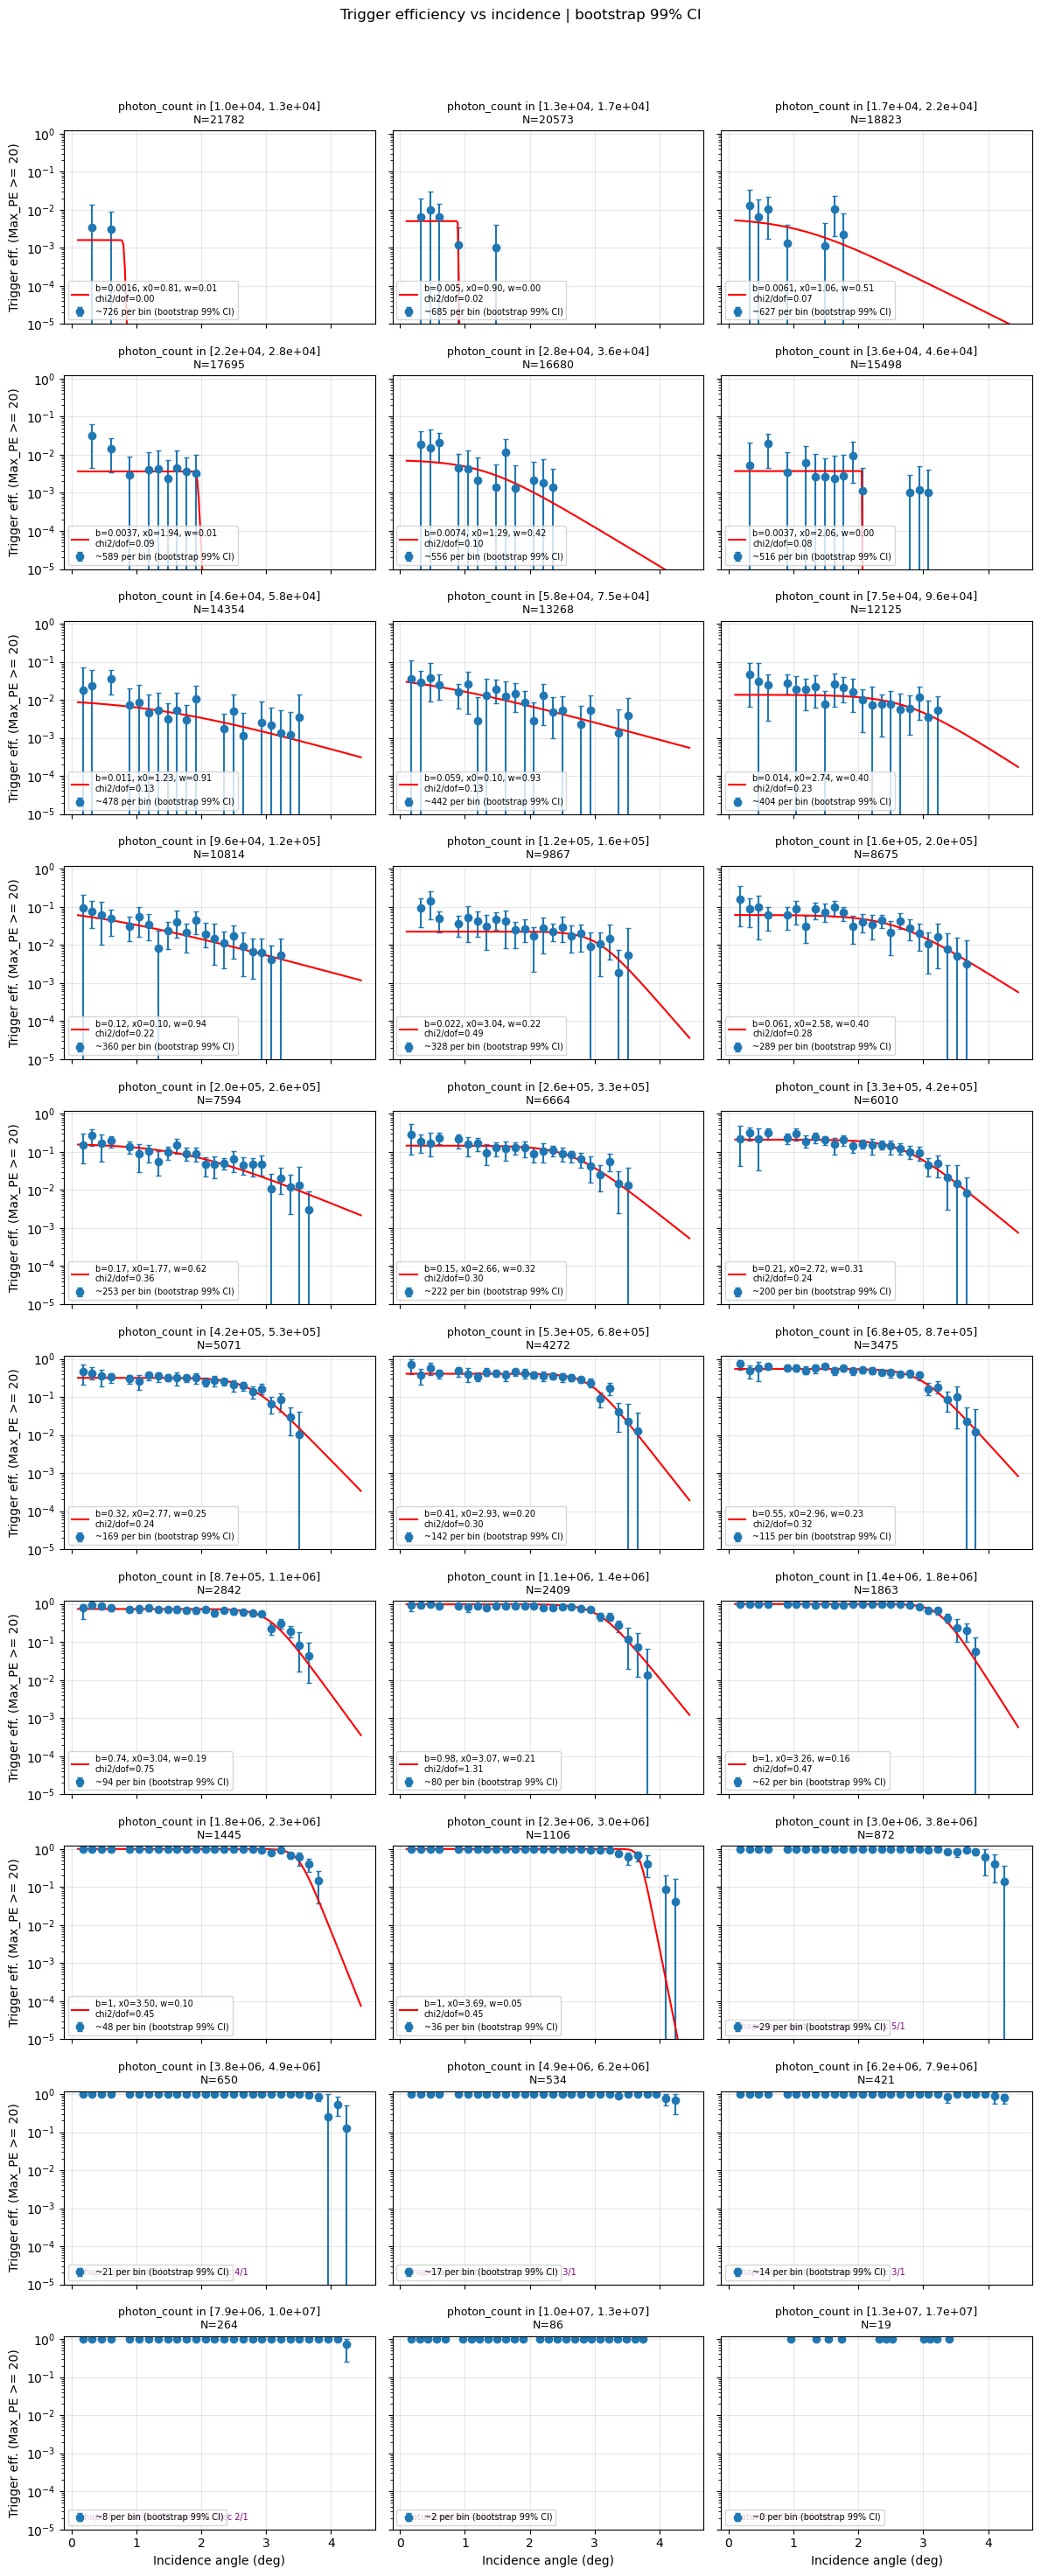

Skipped saturated bins (eff ~ 1 across incidence):
  pc_mean=1.155e+07, N=86
  pc_mean=1.476e+07, N=19
Skipped bins due to incidence-shape check:
  pc_mean=3.384e+06, N=872 | const 22 zero 0 dec_run 5
  pc_mean=4.325e+06, N=650 | const 24 zero 0 dec_run 4
  pc_mean=5.528e+06, N=534 | const 26 zero 0 dec_run 3
  pc_mean=7.067e+06, N=421 | const 24 zero 0 dec_run 3
  pc_mean=9.033e+06, N=264 | const 24 zero 0 dec_run 2
PER-BIN LOGISTIC CUTOFF FIT DIAGNOSTICS
Fit equation: eff(x) = b / (1 + exp((x - x0) / w))
Error bars:   bootstrap 99% CI (N_boot=200)
--------------------------------------------------------------------------------
     pc_mean          b         ±b         x0        ±x0          w         ±w   chi2/dof     minN
--------------------------------------------------------------------------------
   1.195e+04     0.0016     0.0058      0.811    6.5e+08      0.008    6.2e+07       0.00       49
   1.527e+04    0.00473     0.0057      0.899     0.0052      0.001     0.0058      

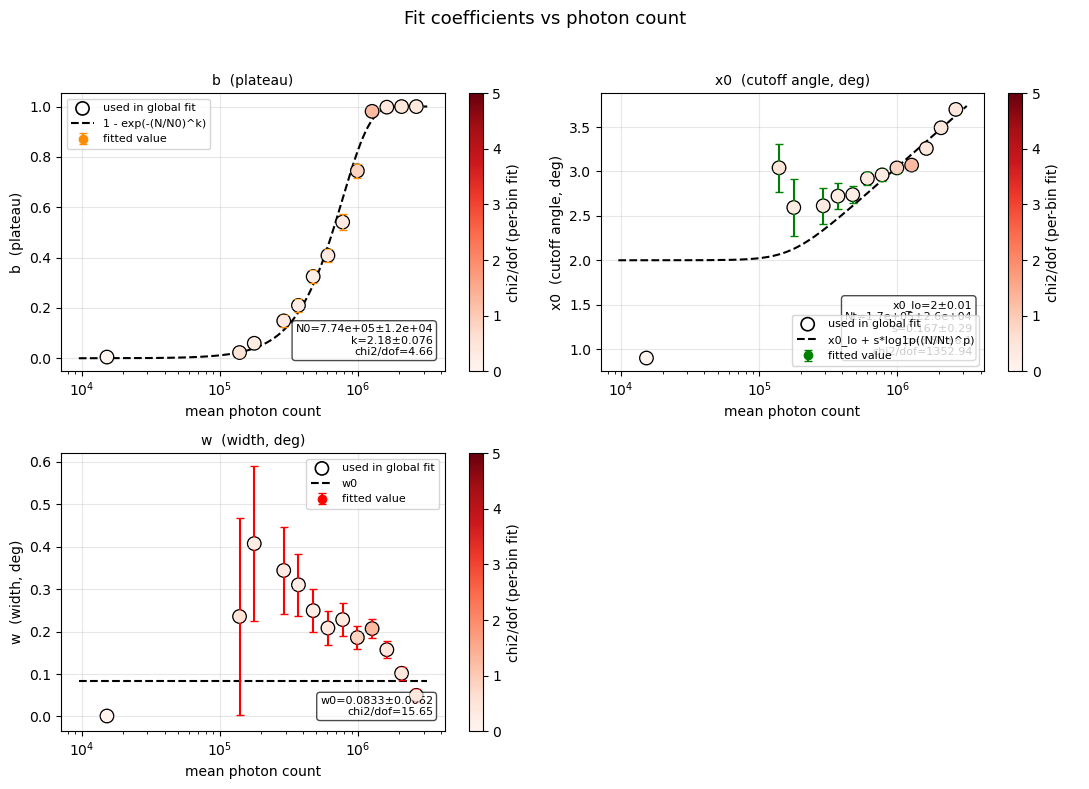


PHYSICAL MODEL FITS (coefficient vs photon count N)

--- Model for parameter 'x0' ---
Equation:  x0(N) = x0_lo + s * log1p((N/Nt)^p)
         x0_lo = 2 ± 0.01
            Nt = 1.704e+05 ± 2.6e+04
             s = 0.1669 ± 0.29
             p = 3.561 ± 6.1
      chi2/dof = 1352.936

--- Model for parameter 'b' ---
Equation:  b(N)  = 1 - exp(-(N/N0)^k)
            N0 = 7.739e+05 ± 1.2e+04
             k = 2.176 ± 0.076
      chi2/dof = 4.665

--- Model for parameter 'w' ---
Equation:  w(N)  = w0
            w0 = 0.08327 ± 0.0062
      chi2/dof = 15.653


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize

# --- User settings ---
PE_THRESHOLD = 20
n_photon_bins = 30
n_inc_bins = 30
ncols = 3
BIAS_QUANTILE = 0.5 #bias toward high incidence value
USE_BIASED_INC_BINS = False
MIN_EVENTS_PER_INC_BIN = 2
MAX_CHI2_DOF = 5.0
MAX_X0_ERR_DEG = 0.5
MAX_W_ERR_DEG = 0.5
EFF_ERR_FLOOR = 0.01
B_ERR_FLOOR = 0.01
W_ERR_FLOOR = 0.01
MIN_PARAM_ERR = 1e-4
SATURATION_EFF = 0.9
B_MIN_SIGNIFICANCE = 0.09

# incidence-shape precheck
MIN_CONST_POINTS = 1
MIN_ZERO_POINTS = 1
MIN_DECREASE_POINTS = 1
ZERO_EFF_MAX = 0.02
CONST_REL_TOL = 0.1
CONST_ABS_TOL = 0.03
DECREASE_TOL = 0.01

N_BOOTSTRAP = 200
CI_LEVEL = 99.0  # percent
CI_ALPHA = (100.0 - CI_LEVEL) / 2.0  # 0.5 for 99%

# ---- bootstrap helper ----
def bootstrap_eff_ci(trig_bin, n_boot=N_BOOTSTRAP, ci_alpha=CI_ALPHA):
    """
    trig_bin: 1D array of 0/1 for events in one incidence bin.
    Returns (eff, err_lo, err_hi) where err_lo/hi are half-CI widths
    suitable for asymmetric errorbar.
    """
    n = len(trig_bin)
    if n == 0:
        return np.nan, np.nan, np.nan
    eff = trig_bin.mean()
    boot_effs = np.array([
        np.random.choice(trig_bin, size=n, replace=True).mean()
        for _ in range(n_boot)
    ])
    lo = np.percentile(boot_effs, ci_alpha)
    hi = np.percentile(boot_effs, 100.0 - ci_alpha)
    # symmetric error for fitting: use half-width of CI
    err = (hi - lo) / 2.0
    err = max(err, EFF_ERR_FLOOR)
    return eff, lo, hi, err

# ---- preprocess ----
mask = (
    np.isfinite(photon_count) & (photon_count > 0) &
    np.isfinite(Max_PE) & (Max_PE > 0) &
    np.isfinite(Incidence)
)

pc = photon_count[mask]
inc = Incidence[mask]
pe = Max_PE[mask]
trig = (pe >= PE_THRESHOLD).astype(float)

pc_for_edges = pc[pe >= PE_THRESHOLD]
pc_edges = np.logspace(min(np.log10(pc_for_edges)), max(np.log10(pc_for_edges)),n_photon_bins + 1)#np.unique(np.quantile(pc_for_edges, np.linspace(0, 1, n_photon_bins + 1)))
n_photon_bins = len(pc_edges) - 1

def logistic_cutoff(x, b, x0, w):
    return b / (1.0 + np.exp((x - x0) / w))

# ---- helper: compute bootstrap eff/err arrays for a slice ----
def compute_bootstrap_arrays(inc_slice, trig_slice, inc_edges):
    """
    For each incidence bin defined by inc_edges, bootstrap the efficiency.
    Returns: eff, err_sym, err_lo, err_hi, total arrays (one per bin).
    """
    n_bins = len(inc_edges) - 1
    eff_arr    = np.full(n_bins, np.nan)
    err_arr    = np.full(n_bins, np.nan)
    err_lo_arr = np.full(n_bins, np.nan)
    err_hi_arr = np.full(n_bins, np.nan)
    total_arr  = np.zeros(n_bins, dtype=int)

    for k in range(n_bins):
        in_bin = (inc_slice >= inc_edges[k]) & (inc_slice < inc_edges[k + 1])
        trig_bin = trig_slice[in_bin]
        total_arr[k] = len(trig_bin)
        if len(trig_bin) == 0:
            continue
        eff, lo, hi, err = bootstrap_eff_ci(trig_bin)
        eff_arr[k]    = eff
        err_lo_arr[k] = eff - lo   # distance below
        err_hi_arr[k] = hi - eff   # distance above
        err_arr[k]    = err

    return eff_arr, err_arr, err_lo_arr, err_hi_arr, total_arr


def build_inc_edges(inc_slice, n_bins, use_bias, bias_quantile, use_linear=True):
    if use_linear:
        return np.linspace(inc_slice.min(), inc_slice.max(), n_bins + 1)
    if use_bias:
        inc_threshold = np.quantile(inc_slice, bias_quantile)
        inc_upper = inc_slice[inc_slice >= inc_threshold]
        if len(inc_upper) >= n_bins:
            inc_edges_upper = np.unique(
                np.quantile(inc_upper, np.linspace(0, 1, n_bins + 1))
            )
            return np.unique(np.concatenate([[inc_slice.min()], inc_edges_upper]))
    return np.unique(np.quantile(inc_slice, np.linspace(0, 1, n_bins + 1)))


def _max_decreasing_run(eff_sorted, dec_tol):
    max_run = 1
    run = 1
    for i in range(1, len(eff_sorted)):
        if eff_sorted[i] < eff_sorted[i - 1] - dec_tol:
            run += 1
        else:
            run = 1
        if run > max_run:
            max_run = run
    return max_run


def check_incidence_shape(
    inc_centers,
    eff,
    total,
    min_total=MIN_EVENTS_PER_INC_BIN,
    min_const=MIN_CONST_POINTS,
    min_zero=MIN_ZERO_POINTS,
    min_dec=MIN_DECREASE_POINTS,
    zero_max=ZERO_EFF_MAX,
    const_rel_tol=CONST_REL_TOL,
    const_abs_tol=CONST_ABS_TOL,
    dec_tol=DECREASE_TOL,
):
    mask = np.isfinite(inc_centers) & np.isfinite(eff) & (total >= min_total)
    if mask.sum() < 3:
        return False, {"n_const": 0, "n_zero": 0, "max_dec_run": 0}

    inc = inc_centers[mask]
    effv = eff[mask]
    order = np.argsort(inc)
    effv = effv[order]

    max_eff = np.nanmax(effv)
    if not np.isfinite(max_eff) or max_eff <= 0:
        return False, {"n_const": 0, "n_zero": 0, "max_dec_run": 0}

    const_tol = max(const_abs_tol, const_rel_tol * max_eff)
    n_const = int(np.sum(max_eff - effv <= const_tol))
    n_zero = int(np.sum(effv <= zero_max))
    max_dec_run = _max_decreasing_run(effv, dec_tol)

    ok = (n_const >= min_const) and (n_zero >= min_zero) and (max_dec_run >= min_dec)
    return ok, {"n_const": n_const, "n_zero": n_zero, "max_dec_run": max_dec_run}

# ======================================================================
# PLOT: trigger efficiency per photon-count bin
# ======================================================================
nrows = int(np.ceil(n_photon_bins / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True
)
axes = np.atleast_1d(axes).ravel()
x_fit = np.linspace(inc.min(), inc.max(), 200)

for i in range(n_photon_bins):
    ax = axes[i]
    pc_lo, pc_hi = pc_edges[i], pc_edges[i + 1]
    sub = (pc >= pc_lo) & (pc < pc_hi)
    n_sub = sub.sum()

    if n_sub == 0:
        ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN=0")
        continue

    inc_sub = inc[sub]
    trig_sub = trig[sub]

    inc_edges = build_inc_edges(inc_sub, n_inc_bins, USE_BIASED_INC_BINS, BIAS_QUANTILE)

    if len(inc_edges) < 3:
        ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN={n_sub}")
        ax.text(0.5, 0.5, "insufficient bins", transform=ax.transAxes,
                ha='center', va='center', fontsize=8, color='red')
        continue

    n_bins_actual = len(inc_edges) - 1
    inc_centers = 0.5 * (inc_edges[:-1] + inc_edges[1:])

    eff, err, err_lo, err_hi, total = compute_bootstrap_arrays(
        inc_sub, trig_sub, inc_edges
    )

    # asymmetric error bars from bootstrap CI
    yerr_asym = np.array([
        np.where(np.isfinite(err_lo), err_lo, 0),
        np.where(np.isfinite(err_hi), err_hi, 0)
    ])

    ax.errorbar(inc_centers, eff, yerr=yerr_asym, fmt='o', capsize=2,
                label=f"~{n_sub // n_bins_actual} per bin (bootstrap {CI_LEVEL:.0f}% CI)")

    eff_valid = eff[np.isfinite(eff)]
    saturated = bool(eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF))

    good = np.isfinite(eff) & (total > 0)
    min_total = int(np.min(total[total > 0])) if np.any(total > 0) else 0

    shape_ok, shape_info = check_incidence_shape(inc_centers, eff, total)

    if saturated:
        ax.text(0.05, 0.05, f"saturated (eff>={SATURATION_EFF:.2f})",
                transform=ax.transAxes, fontsize=7, color='darkred')
    elif shape_ok and good.sum() >= 4 and min_total >= MIN_EVENTS_PER_INC_BIN:
        xd = inc_centers[good]
        yd = eff[good]
        sd = np.where(err[good] > 0, err[good], EFF_ERR_FLOOR)

        inc_range = inc_edges[-1] - inc_edges[0]
        b0 = min(max(np.nanmax(yd), 0.05), 1.0)
        x0_0 = xd[np.argmin(np.abs(yd - 0.5 * np.nanmax(yd)))]
        w0 = max(0.02 * (inc_range + 1e-6), 1e-3)
        p0 = [b0, x0_0, w0]
        bounds = (
            [0.0, inc_edges[0], 1e-3],
            [1.05, inc_edges[-1], 0.4 * inc_range],
        )

        try:
            popt, _ = curve_fit(
                logistic_cutoff, xd, yd, p0=p0, sigma=sd,
                absolute_sigma=True, bounds=bounds, maxfev=20000
            )
            y_model = logistic_cutoff(xd, *popt)
            chi2 = np.sum(((yd - y_model) / sd) ** 2)
            dof = len(xd) - 3
            chi2_dof = chi2 / dof if dof > 0 else np.nan

            ax.plot(x_fit, logistic_cutoff(x_fit, *popt), 'r-', lw=1.5,
                    label=(f"b={popt[0]:.2g}, x0={popt[1]:.2f}, "
                           f"w={popt[2]:.2f}\nchi2/dof={chi2_dof:.2f}"))
        except Exception:
            ax.text(0.05, 0.05, "fit failed", transform=ax.transAxes,
                    fontsize=8, color='red')
    else:
        if not shape_ok:
            msg = (
                f"shape fail: const {shape_info['n_const']}/{MIN_CONST_POINTS}, "
                f"zero {shape_info['n_zero']}/{MIN_ZERO_POINTS}, "
                f"dec {shape_info['max_dec_run']}/{MIN_DECREASE_POINTS}"
            )
            ax.text(0.05, 0.05, msg, transform=ax.transAxes,
                    fontsize=7, color='purple')
        else:
            ax.text(0.05, 0.05, f"low stats (min N={min_total})",
                    transform=ax.transAxes, fontsize=7, color='darkred')

    ax.legend(fontsize=7, loc='lower left')
    ax.set_ylim(1e-5, 1.2)
    ax.set_yscale("log")
    ax.set_title(f"photon_count in [{pc_lo:.1e}, {pc_hi:.1e}]\nN={n_sub}", fontsize=9)
    ax.grid(alpha=0.3)

for j in range(n_photon_bins, len(axes)):
    axes[j].set_visible(False)

for ax in axes[:n_photon_bins]:
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel("Incidence angle (deg)")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")

fig.suptitle(f"Trigger efficiency vs incidence | bootstrap {CI_LEVEL:.0f}% CI", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ======================================================================
# PER-BIN FIT LOOP
# ======================================================================
pc_means, x0_vals, x0_errs = [], [], []
b_vals, b_errs = [], []
w_vals, w_errs = [], []
chi2_vals = []
min_counts = []
mean_counts = []
saturated_bins = []
saturated_ranges = []
shape_failed_bins = []

for i in range(n_photon_bins):
    pc_lo, pc_hi = pc_edges[i], pc_edges[i + 1]
    sub = (pc >= pc_lo) & (pc < pc_hi)
    if sub.sum() == 0:
        continue

    inc_sub = inc[sub]
    trig_sub = trig[sub]

    inc_edges = build_inc_edges(inc_sub, n_inc_bins, USE_BIASED_INC_BINS, BIAS_QUANTILE)
    if len(inc_edges) < 3:
        continue

    inc_centers = 0.5 * (inc_edges[:-1] + inc_edges[1:])
    inc_range = inc_edges[-1] - inc_edges[0]

    eff, err, err_lo, err_hi, total = compute_bootstrap_arrays(
        inc_sub, trig_sub, inc_edges
    )

    eff_valid = eff[np.isfinite(eff)]
    if eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF):
        saturated_bins.append((0.5 * (pc_lo + pc_hi), int(sub.sum())))
        saturated_ranges.append((pc_lo, pc_hi))
        continue

    shape_ok, shape_info = check_incidence_shape(inc_centers, eff, total)
    if not shape_ok:
        shape_failed_bins.append((0.5 * (pc_lo + pc_hi), int(sub.sum()), shape_info))
        continue

    good = np.isfinite(eff) & (total > 0)
    if good.sum() < 4:
        continue

    xd = inc_centers[good]
    yd = eff[good]
    sd = np.where(err[good] > 0, err[good], EFF_ERR_FLOOR)

    min_total = int(np.min(total[total > 0])) if np.any(total > 0) else 0
    mean_total = float(np.mean(total[total > 0])) if np.any(total > 0) else 0.0

    b0 = min(max(np.nanmax(yd), 0.05), 1.0)
    x0_0 = xd[np.argmin(np.abs(yd - 0.5 * np.nanmax(yd)))]
    w0 = max(0.02 * (inc_range + 1e-6), 1e-3)
    p0 = [b0, x0_0, w0]
    bounds = (
        [0.0, inc_edges[0], 1e-3],
        [1.05, inc_edges[-1], 0.4 * inc_range],
    )

    try:
        popt, pcov = curve_fit(
            logistic_cutoff, xd, yd, p0=p0, sigma=sd,
            absolute_sigma=True, bounds=bounds, maxfev=20000
        )
        perr = np.sqrt(np.diag(pcov))
        y_model = logistic_cutoff(xd, *popt)
        chi2 = np.sum(((yd - y_model) / sd) ** 2)
        dof = len(xd) - 3
        chi2_dof = chi2 / dof if dof > 0 else np.nan

        pc_means.append(0.5 * (pc_lo + pc_hi))
        b_vals.append(popt[0]);  b_errs.append(perr[0])
        x0_vals.append(popt[1]); x0_errs.append(perr[1])
        w_vals.append(popt[2]);  w_errs.append(perr[2])
        chi2_vals.append(chi2_dof)
        min_counts.append(min_total)
        mean_counts.append(mean_total)

    except Exception:
        continue

if saturated_bins:
    print("Skipped saturated bins (eff ~ 1 across incidence):")
    for pc_mean, n_sub in saturated_bins:
        print(f"  pc_mean={pc_mean:.3e}, N={n_sub}")

if shape_failed_bins:
    print("Skipped bins due to incidence-shape check:")
    for pc_mean, n_sub, info in shape_failed_bins:
        print(
            f"  pc_mean={pc_mean:.3e}, N={n_sub} | const {info['n_const']} "
            f"zero {info['n_zero']} dec_run {info['max_dec_run']}"
        )

pc_means   = np.array(pc_means)
b_vals,  b_errs  = np.array(b_vals),  np.array(b_errs)
x0_vals, x0_errs = np.array(x0_vals), np.array(x0_errs)
w_vals,  w_errs  = np.array(w_vals),  np.array(w_errs)
chi2_vals  = np.array(chi2_vals)
min_counts = np.array(min_counts)
mean_counts = np.array(mean_counts)

# -- quality mask --
cutoff_in_range = (
    (x0_vals + 2.0 * w_vals <= inc.max()) &
    (x0_vals - 2.0 * w_vals >= inc.min())
)
finite_mask = (
    np.isfinite(chi2_vals) & np.isfinite(x0_errs) &
    np.isfinite(w_errs) & np.isfinite(b_errs)
)
stats_mask = min_counts >= MIN_EVENTS_PER_INC_BIN
err_mask = (
    (x0_errs < MAX_X0_ERR_DEG) & (w_errs < MAX_W_ERR_DEG) &
    (b_errs > MIN_PARAM_ERR) & (x0_errs > MIN_PARAM_ERR) & (w_errs > MIN_PARAM_ERR)
)
chi2_mask = chi2_vals < MAX_CHI2_DOF

with np.errstate(divide='ignore', invalid='ignore'):
    b_signif = np.where(b_errs > 0, b_vals / b_errs, 0.0)
b_signif_mask = b_signif >= B_MIN_SIGNIFICANCE

quality_mask = (
    finite_mask & stats_mask & err_mask &
    chi2_mask & cutoff_in_range & b_signif_mask
)

# -- diagnostics print --
print("=" * 80)
print("PER-BIN LOGISTIC CUTOFF FIT DIAGNOSTICS")
print("=" * 80)
print("Fit equation: eff(x) = b / (1 + exp((x - x0) / w))")
print(f"Error bars:   bootstrap {CI_LEVEL:.0f}% CI (N_boot={N_BOOTSTRAP})")
print("-" * 80)
print(f"{'pc_mean':>12} {'b':>10} {'±b':>10} {'x0':>10} {'±x0':>10} "
      f"{'w':>10} {'±w':>10} {'chi2/dof':>10} {'minN':>8}")
print("-" * 80)
for i in range(len(pc_means)):
    print(f"{pc_means[i]:12.3e} "
          f"{b_vals[i]:10.3g} {b_errs[i]:10.2g} "
          f"{x0_vals[i]:10.3f} {x0_errs[i]:10.2g} "
          f"{w_vals[i]:10.3f} {w_errs[i]:10.2g} "
          f"{chi2_vals[i]:10.2f} {min_counts[i]:8d}")
print("-" * 80)
print(f"Bins fitted: {len(pc_means)} | Bins used for global fits: {int(np.sum(quality_mask))}")
print("=" * 80)

dropped = ~quality_mask
if np.any(dropped):
    print("\nBins EXCLUDED from global fits:")
    print(f"{'pc_mean':>12} {'b/σ_b':>8} {'chi2/dof':>10} {'minN':>8}  reasons")
    for i in np.where(dropped)[0]:
        reasons = []
        if not finite_mask[i]:     reasons.append("nonfinite")
        if not stats_mask[i]:      reasons.append(f"minN<{MIN_EVENTS_PER_INC_BIN}")
        if not err_mask[i]:        reasons.append("err-cut")
        if not chi2_mask[i]:       reasons.append(f"chi2>{MAX_CHI2_DOF}")
        if not cutoff_in_range[i]: reasons.append("x0 out of range")
        if not b_signif_mask[i]:   reasons.append(f"b/σ_b<{B_MIN_SIGNIFICANCE}")
        bs = b_signif[i] if np.isfinite(b_signif[i]) else 0.0
        print(f"{pc_means[i]:12.3e} {bs:8.2f} {chi2_vals[i]:10.2f} "
              f"{min_counts[i]:8d}  " + ", ".join(reasons))

# -- physical models --
def x0_softplus(N, x0_lo, Nt, s, p):
    N = np.maximum(N, 1e-12)
    Nt = np.maximum(Nt, 1e-12)
    return x0_lo + s * np.log1p((N / Nt) ** p)

def plateau_model(N, N0, k):
    N = np.maximum(N, 1e-12)
    return 1.0 - np.exp(-(N / N0) ** k)

def w_const(N, w0):
    return np.full_like(N, w0, dtype=float)

results = {}

def fit_model(fn, xdata, ydata, yerr, p0, bounds):
    sigma = np.where(yerr > 0, yerr, EFF_ERR_FLOOR)
    popt, pcov = curve_fit(
        fn, xdata, ydata, p0=p0, sigma=sigma,
        absolute_sigma=True, bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    residuals = ydata - fn(xdata, *popt)
    chi2 = np.sum((residuals / sigma) ** 2)
    dof = len(xdata) - len(popt)
    chi2_dof = chi2 / dof if dof > 0 else np.nan
    return popt, perr, chi2_dof

ok_x0 = quality_mask & np.isfinite(x0_errs)
try:
    popt, perr, c2 = fit_model(
        x0_softplus, pc_means[ok_x0], x0_vals[ok_x0],
        np.maximum(x0_errs[ok_x0], W_ERR_FLOOR),
        p0=[3.0, 1e6, 0.5, 2.0],
        bounds=([2.0, 1e5, 0.0, 0.5], [5.0, 1e7, 5.0, 10.0])
    )
    results['x0'] = (popt, perr, c2)
except Exception as e:
    print(f"x0 model fit failed: {e}")

ok_b = quality_mask & (b_vals < 0.99) & np.isfinite(b_errs)
try:
    popt, perr, c2 = fit_model(
        plateau_model, pc_means[ok_b], b_vals[ok_b],
        np.maximum(b_errs[ok_b], B_ERR_FLOOR),
        p0=[np.median(pc_means[ok_b]), 1.0],
        bounds=([pc_means.min() * 0.1, 0.1], [pc_means.max() * 10.0, 10.0])
    )
    results['b'] = (popt, perr, c2)
except Exception as e:
    print(f"b model fit failed: {e}")

ok_w = quality_mask & np.isfinite(w_errs) & (w_vals > 0)
try:
    w0 = float(np.nanmedian(w_vals[ok_w])) if np.any(ok_w) else 0.2
    popt, perr, c2 = fit_model(
        w_const, pc_means[ok_w], w_vals[ok_w],
        np.maximum(w_errs[ok_w], W_ERR_FLOOR),
        p0=[w0], bounds=([0.01], [1.0])
    )
    results['w'] = (popt, perr, c2)
except Exception as e:
    print(f"w model fit failed: {e}")

# -- comparison plot --
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
N_smooth = np.linspace(pc_means.min() * 0.8, pc_means.max() * 1.2, 300)

labels      = ['b  (plateau)', 'x0  (cutoff angle, deg)', 'w  (width, deg)']
yvals       = [b_vals, x0_vals, w_vals]
yerrs       = [b_errs, x0_errs, w_errs]
colors      = ['darkorange', 'green', 'red']
model_keys  = ['b', 'x0', 'w']
model_fns   = [plateau_model, x0_softplus, w_const]
model_labels = {
    'x0': r"x0_lo + s*log1p((N/Nt)^p)",
    'b':  r"1 - exp(-(N/N0)^k)",
    'w':  r"w0",
}
param_names = {
    'x0': ['x0_lo', 'Nt', 's', 'p'],
    'b':  ['N0', 'k'],
    'w':  ['w0'],
}

for ax, lbl, yv, ye, col, mkey, mfn in zip(
        axes[:len(labels)], labels, yvals, yerrs, colors, model_keys, model_fns):

    qm = quality_mask
    ax.errorbar(pc_means[qm], yv[qm], yerr=ye[qm], fmt='o', color=col,
                capsize=3, label='fitted value', zorder=3)
    sc = ax.scatter(pc_means[qm], yv[qm], c=chi2_vals[qm], cmap='Reds',
                    vmin=0, vmax=5, zorder=5, s=60)
    plt.colorbar(sc, ax=ax, label='chi2/dof (per-bin fit)')
    ax.scatter(pc_means[qm], yv[qm],
               facecolors='none', edgecolors='black', s=90,
               linewidths=1.2, label='used in global fit')

    if mkey in results:
        popt, perr, c2 = results[mkey]
        ax.plot(N_smooth, mfn(N_smooth, *popt), 'k--',
                lw=1.5, label=model_labels[mkey])
        txt = "\n".join(f"{n}={v:.3g}±{e:.2g}"
                        for n, v, e in zip(param_names[mkey], popt, perr))
        txt += f"\nchi2/dof={c2:.2f}"
        ax.text(0.97, 0.05, txt, transform=ax.transAxes, fontsize=8,
                ha='right', va='bottom',
                bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    ax.set_xscale('log')
    ax.set_xlabel('mean photon count')
    ax.set_ylabel(lbl)
    ax.set_title(lbl, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[len(labels):]:
    ax.axis('off')

fig.suptitle("Fit coefficients vs photon count", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# -- physical model summary --
print("\n" + "=" * 80)
print("PHYSICAL MODEL FITS (coefficient vs photon count N)")
print("=" * 80)
model_equations = {
    'x0': "x0(N) = x0_lo + s * log1p((N/Nt)^p)",
    'b':  "b(N)  = 1 - exp(-(N/N0)^k)",
    'w':  "w(N)  = w0",
}
for key in ['x0', 'b', 'w']:
    print(f"\n--- Model for parameter '{key}' ---")
    print(f"Equation:  {model_equations[key]}")
    if key in results:
        popt, perr, c2 = results[key]
        for name, val, err in zip(param_names[key], popt, perr):
            print(f"  {name:>12} = {val:.4g} ± {err:.2g}")
        print(f"  {'chi2/dof':>12} = {c2:.3f}")
    else:
        print("  FIT FAILED or not available")
print("=" * 80)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm

# ---- extract global-fit parameters ----
b_N0, b_k          = results['b'][0]
x0_lo, x0_Nt, x0_s, x0_p = results['x0'][0]
w0,                = results['w'][0]

if saturated_ranges:
    sat_pc_min = min(r[0] for r in saturated_ranges)
else:
    sat_pc_min = np.inf

def optical_efficiency(photon_counts, incidence):
    N = np.asarray(photon_counts, dtype=float)
    x = np.asarray(incidence,     dtype=float)

    # broadcast N and x to a common shape
    N, x = np.broadcast_arrays(N, x)

    b  = 1.0 - np.exp(-(N / b_N0) ** b_k)
    x0 = x0_lo + x0_s * np.log1p((N / x0_Nt) ** x0_p)
    w  = np.full_like(b, w0)

    z   = np.clip((x - x0) / w, -50.0, 50.0)
    eff = b / (1.0 + np.exp(z))

    return np.clip(eff, 0.0, 1.0)

def eff_vs_zenith(N, theta_z_deg, psi_deg, phi_max_deg=4.0, n_phi=1000):
    """
    Average efficiency over azimuth range [0, phi_max],
    for a source at zenith angle theta_z,
    telescope pointing at zenith angle psi.

    Parameters
    ----------
    N           : photon count
    theta_z_deg : source zenith angle (deg)
    psi_deg     : telescope pointing zenith angle (deg)
    phi_max_deg : azimuth integration range (deg)
    """
    phi     = np.linspace(0, np.radians(phi_max_deg), n_phi)  # (n_phi,)
    theta_z = np.radians(np.asarray(theta_z_deg, dtype=float))  # (n_z,) or scalar
    psi     = np.radians(psi_deg)

    # reshape for broadcasting: theta_z -> (..., 1), phi -> (n_phi,)
    theta_z = theta_z[..., np.newaxis]  # (n_z, 1)

    # opening angle from telescope axis via spherical law of cosines
    cos_theta = (np.cos(psi) * np.cos(theta_z) +
                 np.sin(psi) * np.sin(theta_z) * np.cos(phi))  # (n_z, n_phi)

    cos_theta = np.clip(cos_theta, -1, 1)
    theta_inc = np.degrees(np.arccos(cos_theta))  # (n_z, n_phi)

    eff_vals = optical_efficiency(N, theta_inc)    # (n_z, n_phi)

    # integrate over phi axis (axis=-1)
    return np.trapezoid(eff_vals, phi, axis=-1) / (phi[-1] - phi[0])  # (n_z,)

# ---- 2D efficiency map (fit) ----
N_grid   = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 400)
inc_grid = np.linspace(inc.min(), inc.max(), 400)
NN, XX   = np.meshgrid(N_grid, inc_grid)
EFF      = optical_efficiency(NN, XX)

# ---- 2D histogram (data) ----
N_edges   = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 31)
inc_edges = np.linspace(inc.min(), inc.max(), 11)

total_2d,    _, _ = np.histogram2d(pc, inc, bins=[N_edges, inc_edges])
triggered_2d, _, _ = np.histogram2d(
    pc[trig == 1], inc[trig == 1], bins=[N_edges, inc_edges]
)

with np.errstate(divide='ignore', invalid='ignore'):
    eff_data = np.where(total_2d > 0, triggered_2d / total_2d, np.nan)

norm = SymLogNorm(linthresh=1e-3, linscale=1.0, vmin=0.0, vmax=1.0, base=10)
x0_curve = x0_lo + x0_s * np.log1p((N_grid / x0_Nt) ** x0_p)

# ---- side-by-side plot ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: fit ---
ax = axes[0]
pcm0 = ax.pcolormesh(NN, XX, EFF, shading='auto', cmap='viridis', norm=norm)
ax.plot(N_grid, x0_curve,       'w--', lw=1.5, label=r'$x_0(N)$ (cutoff)')
ax.plot(N_grid, x0_curve - w0,  'w:',  lw=1.0, alpha=0.7, label=r'$x_0 \pm w$')
ax.plot(N_grid, x0_curve + w0,  'w:',  lw=1.0, alpha=0.7)
ax.set_xscale('log')
ax.set_xlim(N_grid.min(), N_grid.max())
ax.set_ylim(inc.min(), inc.max())
ax.set_xlabel('photon count  N')
ax.set_ylabel('incidence angle  (deg)')
ax.set_title('Global fit  eff(N, x)')
cbar0 = fig.colorbar(pcm0, ax=ax)
cbar0.set_label('efficiency')
ax.legend(loc='upper left', framealpha=0.8)
ax.grid(alpha=0.2, which='both')

# --- right: data ---
ax = axes[1]
pcm1 = ax.pcolormesh(
    N_edges, inc_edges, eff_data.T,
    shading='flat', cmap='viridis', norm=norm
)
ax.set_xscale('log')
ax.set_xlim(N_edges.min(), N_edges.max())
ax.set_ylim(inc.min(), inc.max())
ax.set_xlabel('photon count  N')
ax.set_ylabel('incidence angle  (deg)')
ax.set_title('Data trigger efficiency')
cbar1 = fig.colorbar(pcm1, ax=ax)
cbar1.set_label('trigger efficiency (data)')
ax.grid(alpha=0.2, which='both')

fig.tight_layout()
plt.show()
# ---- 2D histogram: data efficiency vs fit prediction ----

# count total and triggered events in each 2D bin
total_2d,   _, _ = np.histogram2d(pc, inc, bins=[N_edges, inc_edges])
triggered_2d, _, _ = np.histogram2d(
    pc[trig == 1], inc[trig == 1], bins=[N_edges, inc_edges]
)

# data efficiency per bin
with np.errstate(divide='ignore', invalid='ignore'):
    eff_data = np.where(total_2d > 0, triggered_2d / total_2d, np.nan)

# fit prediction at bin centers
N_centers   = 0.5 * (N_edges[:-1]   + N_edges[1:])
inc_centers = 0.5 * (inc_edges[:-1] + inc_edges[1:])
NN_c, XX_c  = np.meshgrid(N_centers, inc_centers, indexing='ij')
eff_fit     = optical_efficiency(NN_c, XX_c)

# ---- chi-square per degree of freedom ----
with np.errstate(divide='ignore', invalid='ignore'):
    sigma_data = np.where(
        total_2d > 0,
        np.sqrt(eff_data * (1.0 - eff_data) / total_2d),
        np.nan,
    )

with np.errstate(divide='ignore', invalid='ignore'):
    chi2_2d = np.where(
        (sigma_data > 0) & np.isfinite(eff_data) & (total_2d >= MIN_EVENTS_PER_INC_BIN),
        ((eff_data - eff_fit) / sigma_data) ** 2,
        np.nan,
    )

n_free_params = 3
valid_mask = np.isfinite(chi2_2d)
n_valid    = valid_mask.sum()
dof        = n_valid - n_free_params

chi2_total    = np.nansum(chi2_2d)
chi2_per_dof  = chi2_total / dof if dof > 0 else np.nan

print(f"\nGlobal chi2 / dof = {chi2_total:.2f} / {dof} = {chi2_per_dof:.3f}")

# ---- plot chi2 map only ----
fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    N_edges, inc_edges,
    chi2_2d.T,
    shading='flat',
    cmap='plasma',
    norm=SymLogNorm(linthresh=0.5, linscale=0.5, vmin=0.0, vmax=25.0, base=10),
)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r'$\chi^2$ per bin')
ax.set_xscale('log')
ax.set_xlabel('photon count  N')
ax.set_ylabel('incidence angle  (deg)')
ax.set_title(
    f'Per-bin $\\chi^2$  '
    f'[total $\\chi^2$/dof = {chi2_total:.1f}/{dof} = {chi2_per_dof:.2f}]'
)
ax.grid(alpha=0.2, which='both')

fig.tight_layout()
plt.show()


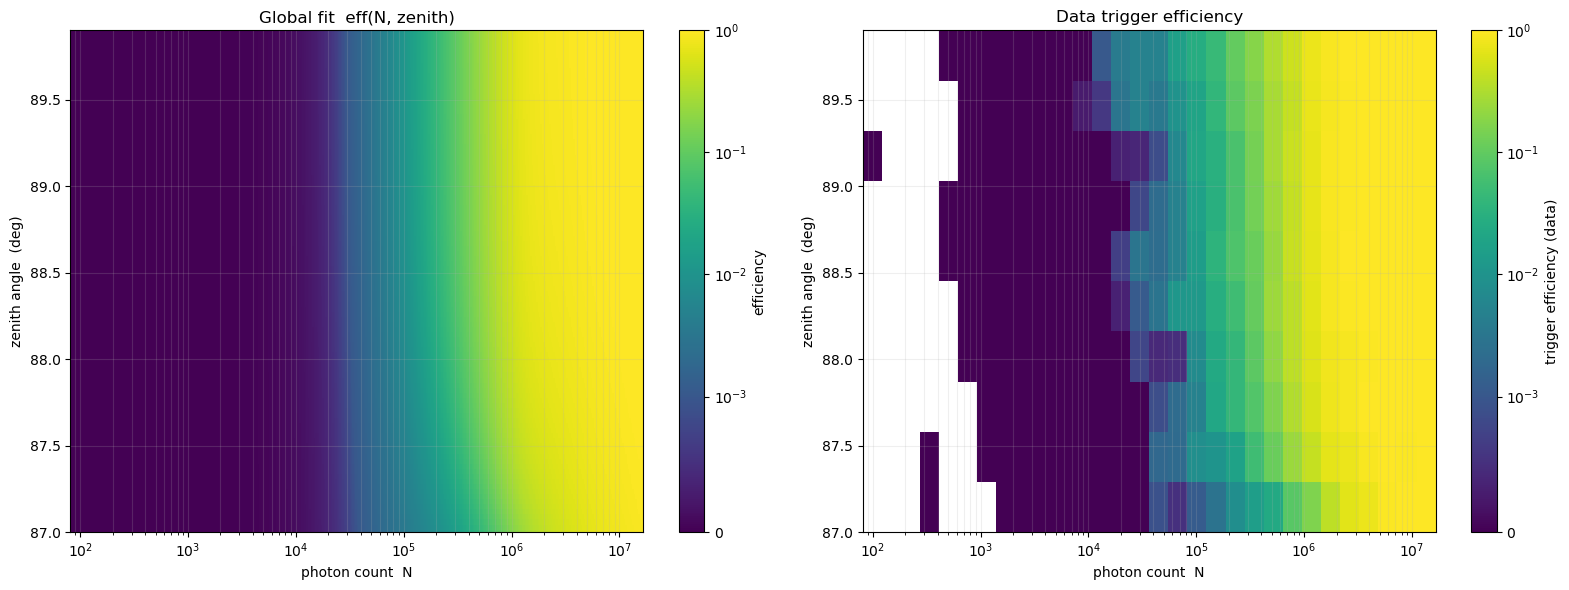


Global chi2 / dof = 2291.18 / 139 = 16.483


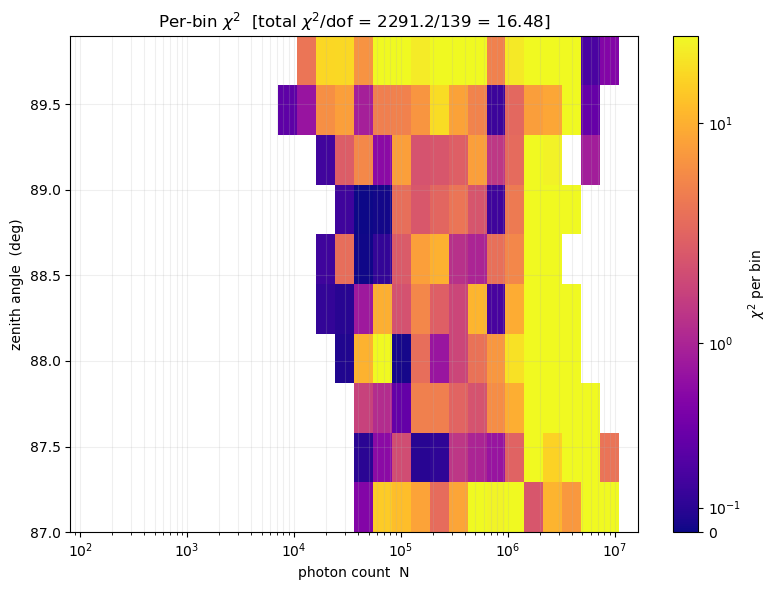

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

# ---- extract global-fit parameters ----
"""b_N0, b_k                 = results['b'][0]
x0_lo, x0_Nt, x0_s, x0_p = results['x0'][0]
w0,                       = results['w'][0]"""

b_N0, b_k          = results['b'][0];  cov_b  = results['b'][1]
x0_lo, x0_Nt, x0_s, x0_p = results['x0'][0]; cov_x0 = results['x0'][1]
w_inf, w_A, w_alpha = results['w'][0];  cov_w  = results['w'][1]

if saturated_ranges:
    sat_pc_min = min(r[0] for r in saturated_ranges)
else:
    sat_pc_min = np.inf


def optical_efficiency(photon_counts, incidence):
    N = np.asarray(photon_counts, dtype=float)
    x = np.asarray(incidence,     dtype=float)
    N, x = np.broadcast_arrays(N, x)
    b  = 1.0 - np.exp(-(N / b_N0) ** b_k)
    x0 = x0_lo + x0_s * np.log1p((N / x0_Nt) ** x0_p)
    w  = w_inf + w_A * N**(-w_alpha)
    z  = np.clip((x - x0) / w, -50.0, 50.0)
    return np.clip(b / (1.0 + np.exp(z)), 0.0, 1.0)


def eff_vs_zenith_vectorized(N_arr, theta_z_arr, psi_deg, phi_max_deg=4.0, n_phi=20):
    """
    Fully vectorized azimuth-averaged efficiency.

    Parameters
    ----------
    N_arr       : (n_N,)   photon counts
    theta_z_arr : (n_zen,) zenith angles in degrees
    psi_deg     : float    muon incidence angle in degrees

    Returns
    -------
    EFF : (n_zen, n_N) azimuth-averaged efficiency
    """
    phi     = np.linspace(0.0, np.radians(phi_max_deg), n_phi)          # (n_phi,)
    theta_z = np.radians(np.asarray(theta_z_arr, dtype=float))          # (n_zen,)
    psi     = np.radians(float(psi_deg))

    # cos_theta: (n_zen, n_phi)
    cos_theta = (
        np.cos(psi) * np.cos(theta_z)[:, np.newaxis]
        + np.sin(psi) * np.sin(theta_z)[:, np.newaxis] * np.cos(phi)[np.newaxis, :]
    )
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta_inc = np.degrees(np.arccos(cos_theta))                         # (n_zen, n_phi)

    # broadcast to (n_N, n_zen, n_phi)
    N_3d     = np.asarray(N_arr, dtype=float)[:, np.newaxis, np.newaxis]
    theta_3d = theta_inc[np.newaxis, :, :]                              # (1, n_zen, n_phi)

    eff_vals = optical_efficiency(N_3d, theta_3d)                        # (n_N, n_zen, n_phi)

    # integrate over phi, normalize -> (n_N, n_zen)
    avg = np.trapezoid(eff_vals, phi, axis=-1) / (phi[-1] - phi[0])

    return avg.T                                                         # (n_zen, n_N)


# =========================================================================
# Grids and edges  (defined once, reused everywhere)
# =========================================================================
N_grid    = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 400)
zen_grid  = np.linspace(Zenith.min(), Zenith.max(), 100)

N_edges   = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 31)
zen_edges = np.linspace(Zenith.min(), Zenith.max(), 11)

N_centers   = 0.5 * (N_edges[:-1]  + N_edges[1:])
zen_centers = 0.5 * (zen_edges[:-1] + zen_edges[1:])

# =========================================================================
# Efficiency maps  (each computed with a single vectorized call)
# =========================================================================
# (n_zen, n_N)  — fine grid for the colour-mesh plot
EFF = eff_vs_zenith_vectorized(N_grid, zen_grid, psi_deg=90)

# (n_zen_bins, n_N_bins)  — bin-centre predictions for chi-square
EFF_fit_bins = eff_vs_zenith_vectorized(N_centers, zen_centers, psi_deg=90)
# transpose to (n_N_bins, n_zen_bins) to match histogram2d output shape
eff_fit = EFF_fit_bins.T

NN, ZZ = np.meshgrid(N_grid, zen_grid)                                  # (n_zen, n_N)

# =========================================================================
# 2-D histograms  (computed once, reused in both figures)
# =========================================================================
Zenith_masked = Zenith[mask]
trig_mask     = trig == 1

total_2d,     _, _ = np.histogram2d(pc,              Zenith_masked,             bins=[N_edges, zen_edges])
triggered_2d, _, _ = np.histogram2d(pc[trig_mask],   Zenith_masked[trig_mask],  bins=[N_edges, zen_edges])

with np.errstate(divide='ignore', invalid='ignore'):
    eff_data = np.where(total_2d > 0, triggered_2d / total_2d, np.nan)

# =========================================================================
# Figure 1 — side-by-side: fit map  |  data map
# =========================================================================
norm_eff = SymLogNorm(linthresh=1e-3, linscale=1.0, vmin=0.0, vmax=1.0, base=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: fit ---
ax = axes[0]
pcm0 = ax.pcolormesh(NN, ZZ, EFF, shading='auto', cmap='viridis', norm=norm_eff)
ax.set_xscale('log')
ax.set_xlim(N_grid.min(),  N_grid.max())
ax.set_ylim(Zenith.min(), Zenith.max())
ax.set_xlabel('photon count  N')
ax.set_ylabel('zenith angle  (deg)')
ax.set_title('Global fit  eff(N, zenith)')
fig.colorbar(pcm0, ax=ax).set_label('efficiency')
ax.grid(alpha=0.2, which='both')

# --- right: data ---
ax = axes[1]
pcm1 = ax.pcolormesh(
    N_edges, zen_edges, eff_data.T,
    shading='flat', cmap='viridis', norm=norm_eff,
)
ax.set_xscale('log')
ax.set_xlim(N_edges.min(), N_edges.max())
ax.set_ylim(Zenith.min(),  Zenith.max())
ax.set_xlabel('photon count  N')
ax.set_ylabel('zenith angle  (deg)')
ax.set_title('Data trigger efficiency')
fig.colorbar(pcm1, ax=ax).set_label('trigger efficiency (data)')
ax.grid(alpha=0.2, which='both')

fig.tight_layout()
plt.show()

# =========================================================================
# Chi-square calculation
# =========================================================================
with np.errstate(divide='ignore', invalid='ignore'):
    sigma_data = np.where(
        total_2d > 0,
        np.sqrt(eff_data * (1.0 - eff_data) / total_2d),
        np.nan,
    )

with np.errstate(divide='ignore', invalid='ignore'):
    chi2_2d = np.where(
        (sigma_data > 0)
        & np.isfinite(eff_data)
        & (total_2d >= MIN_EVENTS_PER_INC_BIN),
        ((eff_data - eff_fit) / sigma_data) ** 2,
        np.nan,
    )

n_free_params = 3
valid_mask    = np.isfinite(chi2_2d)
n_valid       = valid_mask.sum()
dof           = n_valid - n_free_params

chi2_total   = np.nansum(chi2_2d)
chi2_per_dof = chi2_total / dof if dof > 0 else np.nan

print(f"\nGlobal chi2 / dof = {chi2_total:.2f} / {dof} = {chi2_per_dof:.3f}")

# =========================================================================
# Figure 2 — per-bin chi-square map
# =========================================================================
fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    N_edges, zen_edges,
    chi2_2d.T,
    shading='flat',
    cmap='plasma',
    norm=SymLogNorm(linthresh=0.5, linscale=0.5, vmin=0.0, vmax=25.0, base=10),
)
fig.colorbar(pcm, ax=ax).set_label(r'$\chi^2$ per bin')
ax.set_xscale('log')
ax.set_xlabel('photon count  N')
ax.set_ylabel('zenith angle  (deg)')
ax.set_title(
    f'Per-bin $\\chi^2$  '
    f'[total $\\chi^2$/dof = {chi2_total:.1f}/{dof} = {chi2_per_dof:.2f}]'
)
ax.grid(alpha=0.2, which='both')

fig.tight_layout()
plt.show()


80.0 1.8288842429451452e-05
82.5 3.985495198934906e-05
85.0 0.00010258920145182907
87.5 0.006351890713840621
90.0 0.018502341556935017


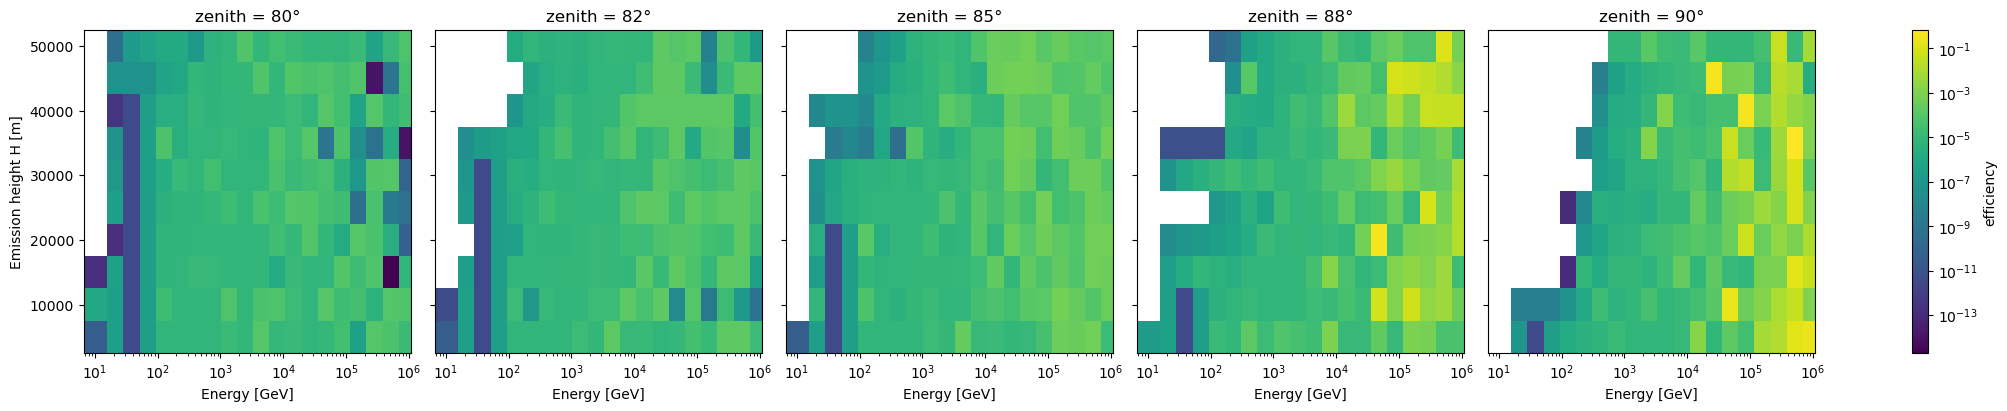

In [7]:
from scipy.interpolate import LinearNDInterpolator

# ---------------------------------------------------------------
# Build photon-count interpolator: N(Energy_GeV, Slant)
# ---------------------------------------------------------------
_pts  = np.column_stack([np.log10(Energy_GeV), Slant])
_vals = photon_count
photon_count_interp = LinearNDInterpolator(_pts, _vals, fill_value=np.nan)

# Precompute, for each unique energy in the data, the min/max slant available
_E_data = np.asarray(Energy_GeV, dtype=float)
_S_data = np.asarray(Slant,      dtype=float)

_unique_E = np.unique(_E_data)
_min_slant_per_E = np.array([_S_data[_E_data == e].min() for e in _unique_E])
_max_slant_per_E = np.array([_S_data[_E_data == e].max() for e in _unique_E])

def _slant_bounds_for_E(E_GeV):
    """Return (min_slant, max_slant) for the closest energy in the data."""
    E_GeV = np.asarray(E_GeV, dtype=float)
    idx = np.argmin(np.abs(np.log10(_unique_E)[None, :]
                           - np.log10(E_GeV).ravel()[:, None]), axis=1)
    return (_min_slant_per_E[idx].reshape(E_GeV.shape),
            _max_slant_per_E[idx].reshape(E_GeV.shape))

def predict_photon_count(E_GeV, slant_km):
    """
    N as a function of (Energy_GeV, Slant[km]). Broadcasts.
    Clamp slant to the [min, max] data range for that energy:
      - H smaller than min H in data -> use smallest-H value
      - H larger  than max H in data -> use largest-H  value
    """
    E_GeV    = np.asarray(E_GeV,    dtype=float)
    slant_km = np.asarray(slant_km, dtype=float)
    E_b, S_b = np.broadcast_arrays(E_GeV, slant_km)

    S_min, S_max = _slant_bounds_for_E(E_b)
    S_clamped = np.clip(S_b, S_min, S_max)

    pts = np.column_stack([np.log10(E_b).ravel(), S_clamped.ravel()])
    return photon_count_interp(pts).reshape(E_b.shape)


# ---------------------------------------------------------------
# Efficiency grid (N_H, N_E) for each zenith
# ---------------------------------------------------------------
OBS_HEIGHT_M = 2944.0
EARTH_R_M    = 6371e3

def efficiency_grid_H_E(H_arr, E_arr, zenith_deg, psi_deg=90,
                        phi_max_deg=4.0, n_phi=100):
    """
    Returns EFF of shape (n_zen, n_H, n_E).

    Parameters
    ----------
    H_arr      : (n_H,)  emission heights [m]
    E_arr      : (n_E,)  energies [GeV]
    zenith_deg : (n_zen,) or scalar zenith angles [deg]
    """
    H_arr      = np.atleast_1d(np.asarray(H_arr,      dtype=float))
    E_arr      = np.atleast_1d(np.asarray(E_arr,      dtype=float))
    zenith_deg = np.atleast_1d(np.asarray(zenith_deg, dtype=float))

    n_H, n_E, n_zen = len(H_arr), len(E_arr), len(zenith_deg)
    EFF = np.full((n_zen, n_H, n_E), np.nan)

    for iz, zen in enumerate(zenith_deg):
        # Slant(H) for this zenith  -> (n_H,)
        S = slant_depth(H_arr + EARTH_R_M,
                        OBS_HEIGHT_M + EARTH_R_M,
                        np.radians(zen)) / 1000.0     # km
        # N(E, Slant) -> (n_H, n_E)
        N_grid_HE = predict_photon_count(E_arr[np.newaxis, :],
                                         S[:, np.newaxis])
        # flatten N, evaluate efficiency at this single zenith
        N_flat = N_grid_HE.ravel()
        valid  = np.isfinite(N_flat) & (N_flat > 0)

        eff_flat = np.full_like(N_flat, np.nan)
        if valid.any():
            # eff_vs_zenith_vectorized returns shape (n_zen=1, n_N)
            result = eff_vs_zenith_vectorized(
            N_flat[valid], [zen],
            psi_deg=psi_deg, phi_max_deg=phi_max_deg, n_phi=n_phi,
        )
            eff_flat[valid] = np.asarray(result).squeeze() 
        EFF[iz] = eff_flat.reshape(n_H, n_E)
    return EFF, H_arr, E_arr, zenith_deg


# ---------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------
H_range      = np.linspace(H.min(),         H.max(),         10)   # m
E_range      = np.logspace(np.log10(Energy_GeV.min()),
                           np.log10(Energy_GeV.max()),       20)   # GeV
zenith_range = np.linspace(80, 90, 5)                    # deg

EFF, H_arr, E_arr, zen_arr = efficiency_grid_H_E(
    H_range, E_range, zenith_range, psi_deg=90,
)

# ---------------------------------------------------------------
# Quick visualization: one panel per zenith
# ---------------------------------------------------------------
ncols = len(zen_arr)
fig, axes = plt.subplots(1, ncols, figsize=(4*ncols, 4),
                         sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)

from matplotlib.colors import LogNorm

eff_positive = np.where(EFF > 0, EFF, np.nan)
vmin = np.nanmin(eff_positive)
vmax = np.nanmax(eff_positive)
norm = LogNorm(vmin=vmin, vmax=vmax)

for ax, zen, eff_slice in zip(axes, zen_arr, EFF):
    eff_plot = np.where(eff_slice > 0, eff_slice, np.nan)
    pcm = ax.pcolormesh(E_arr, H_arr, eff_plot,
                        shading='auto', cmap='viridis', norm=norm)
    ax.set_xscale('log')
    ax.set_xlabel('Energy [GeV]')
    ax.set_title(f'zenith = {zen:.0f}°')
    print(zen, np.nanmean(eff_slice))

axes[0].set_ylabel('Emission height H [m]')
fig.colorbar(pcm, ax=axes, label='efficiency')
plt.show()


In [6]:
from MCEq.core import MCEqRun
import crflux.models as crf
import MCEq.config as config
from MCEq.geometry.density_profiles import MSIS00Atmosphere
from MCEq.geometry.geometry import EarthGeometry
config.kernel_config= 'MKL'
config.e_min = 100 #0.160 # GeV
config.integrator= 'euler'
import numpy as np
import crflux.models as pm
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True

# Initalize MCEq by creating the user interface object MCEqRun
# Initialize custom atmosphere model with coordinates
# Note: Using custom location with latitude/longitude parameters
mag = 0
# Initialize MCEq with custom atmosphere and Frisco Peak location
mceq = MCEqRun(
    # interaction interaction model
    interaction_model='SIBYLL23C',
    # Primary cosmic ray model
    primary_model=(pm.GlobalSplineFitBeta, None),
    # Set to 0° for horizontal muons
    theta_deg=0.,
    # Use custom atmosphere and geometry
    density_model=("CORSIKA", ('USStd', None)),
    #density_model=("MSIS00_IC", ('FriscoPeak', 'January')),
)
#mceq.set_density_model(("CORSIKA", ('USStd', None)))
earth_geom = EarthGeometry()



MCEqRun::set_interaction_model(): SIBYLL23C
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
MCEqRun::set_primary_model(): GlobalSplineFitBeta 


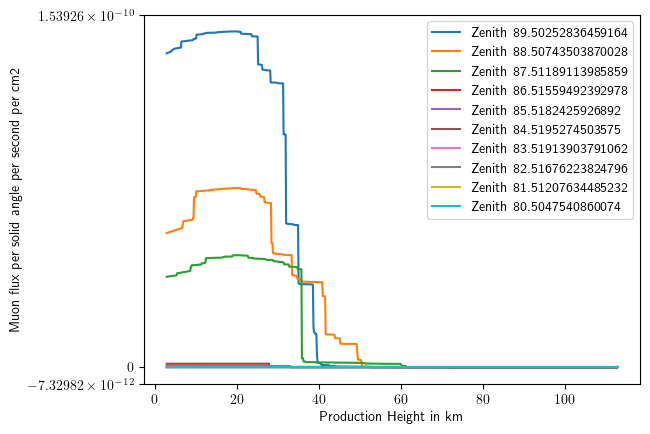

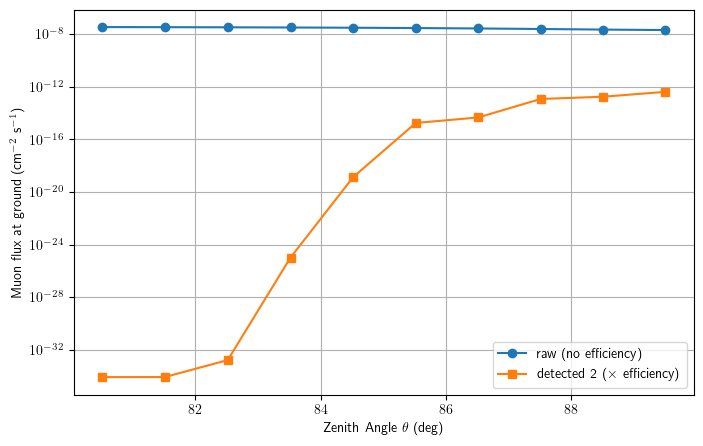

Effective Area (cm^2): 462351.73996121046
Detected muons per hour: 0.0011966755183682486
Total muons per hour: 487.207208646277


In [ ]:
# ---------------------------------------------------------------
# Combined: detected muon rate per zenith
# ---------------------------------------------------------------
Nh = 1000 #Height grid
Nzen=3 #zenith grid
Naz=100 #azimuth grid
min_zen, max_zen = 80,90
min_az, max_az = 260, 270
delta_phi = abs(max_az-min_az)/2
min_E, max_E = 1e2, 1e6

cos_edges = np.linspace(np.cos(np.radians(max_zen)),
                        np.cos(np.radians(min_zen)), Nzen+1)
dcos = np.diff(cos_edges)                       # (Nzen,)
dphi = np.radians(max_az - min_az)
solid_angles = dphi * np.abs(dcos)              # (Nzen,)
zen_centers  = np.degrees(np.arccos(0.5*(cos_edges[:-1]+cos_edges[1:])))

Total_flux_raw      = []   # without efficiency (sanity check)
Total_flux_detected2 = []

b_N0, b_k          = results['b'][0];  cov_b  = results['b'][1]
x0_lo, x0_Nt, x0_s, x0_p = results['x0'][0]; cov_x0 = results['x0'][1]
w0,                = results['w'][0];  cov_w  = results['w'][1]

if saturated_ranges:
    sat_pc_min = min(r[0] for r in saturated_ranges)
else:
    sat_pc_min = np.inf


def optical_efficiency(photon_counts, incidence):
    N = np.asarray(photon_counts, dtype=float)
    x = np.asarray(incidence,     dtype=float)
    N, x = np.broadcast_arrays(N, x)
    b  = 1.0 - np.exp(-(N / b_N0) ** b_k)
    x0 = x0_lo + x0_s * np.log1p((N / x0_Nt) ** x0_p)
    z  = np.clip((x - x0) / w0, -50.0, 50.0)
    return np.clip(b / (1.0 + np.exp(z)), 0.0, 1.0)

def eff_vs_zenith_vectorized(N_arr, theta_z_arr, psi_deg, phi_max_deg=4.0, n_phi=20):
    """
    Fully vectorized azimuth-averaged efficiency.

    Parameters
    ----------
    N_arr       : (n_N,)   photon counts
    theta_z_arr : (n_zen,) zenith angles in degrees
    psi_deg     : float    muon incidence angle in degrees

    Returns
    -------
    EFF : (n_zen, n_N) azimuth-averaged efficiency
    """
    phi     = np.linspace(0.0, np.radians(phi_max_deg), n_phi)          # (n_phi,)
    theta_z = np.radians(np.asarray(theta_z_arr, dtype=float))          # (n_zen,)
    psi     = np.radians(float(psi_deg))

    # cos_theta: (n_zen, n_phi)
    cos_theta = (
        np.cos(psi) * np.cos(theta_z)[:, np.newaxis]
        + np.sin(psi) * np.sin(theta_z)[:, np.newaxis] * np.cos(phi)[np.newaxis, :]
    )
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta_inc = np.degrees(np.arccos(cos_theta))                         # (n_zen, n_phi)

    # broadcast to (n_N, n_zen, n_phi)
    N_3d     = np.asarray(N_arr, dtype=float)[:, np.newaxis, np.newaxis]
    theta_3d = theta_inc[np.newaxis, :, :]                              # (1, n_zen, n_phi)

    eff_vals = optical_efficiency(N_3d, theta_3d)                        # (n_N, n_zen, n_phi)

    # integrate over phi, normalize -> (n_N, n_zen)
    avg = np.trapezoid(eff_vals, phi, axis=-1) / (phi[-1] - phi[0])

    return avg.T      
from scipy.interpolate import LinearNDInterpolator

# ---------------------------------------------------------------
# Build photon-count interpolator: N(Energy_GeV, Slant)
# ---------------------------------------------------------------
_pts  = np.column_stack([np.log10(Energy_GeV), Slant])
_vals = photon_count
photon_count_interp = LinearNDInterpolator(_pts, _vals, fill_value=np.nan)

# Precompute, for each unique energy in the data, the min/max slant available
_E_data = np.asarray(Energy_GeV, dtype=float)
_S_data = np.asarray(Slant,      dtype=float)

_unique_E = np.unique(_E_data)
_min_slant_per_E = np.array([_S_data[_E_data == e].min() for e in _unique_E])
_max_slant_per_E = np.array([_S_data[_E_data == e].max() for e in _unique_E])

def _slant_bounds_for_E(E_GeV):
    """Return (min_slant, max_slant) for the closest energy in the data."""
    E_GeV = np.asarray(E_GeV, dtype=float)
    idx = np.argmin(np.abs(np.log10(_unique_E)[None, :]
                           - np.log10(E_GeV).ravel()[:, None]), axis=1)
    return (_min_slant_per_E[idx].reshape(E_GeV.shape),
            _max_slant_per_E[idx].reshape(E_GeV.shape))

def predict_photon_count(E_GeV, slant_km):
    """
    N as a function of (Energy_GeV, Slant[km]). Broadcasts.
    Clamp slant to the [min, max] data range for that energy:
      - H smaller than min H in data -> use smallest-H value
      - H larger  than max H in data -> use largest-H  value
    """
    E_GeV    = np.asarray(E_GeV,    dtype=float)
    slant_km = np.asarray(slant_km, dtype=float)
    E_b, S_b = np.broadcast_arrays(E_GeV, slant_km)

    S_min, S_max = _slant_bounds_for_E(E_b)
    S_clamped = np.clip(S_b, S_min, S_max)

    pts = np.column_stack([np.log10(E_b).ravel(), S_clamped.ravel()])
    return photon_count_interp(pts).reshape(E_b.shape)


# ---------------------------------------------------------------
# Efficiency grid (N_H, N_E) for each zenith
# ---------------------------------------------------------------
OBS_HEIGHT_M = 2944.0
EARTH_R_M    = 6371e3

def efficiency_grid_H_E(H_arr, E_arr, zenith_deg, psi_deg=90,
                        phi_max_deg=4.0, n_phi=100):
    """
    Returns EFF of shape (n_zen, n_H, n_E).

    Parameters
    ----------
    H_arr      : (n_H,)  emission heights [m]
    E_arr      : (n_E,)  energies [GeV]
    zenith_deg : (n_zen,) or scalar zenith angles [deg]
    """
    H_arr      = np.atleast_1d(np.asarray(H_arr,      dtype=float))
    E_arr      = np.atleast_1d(np.asarray(E_arr,      dtype=float))
    zenith_deg = np.atleast_1d(np.asarray(zenith_deg, dtype=float))

    n_H, n_E, n_zen = len(H_arr), len(E_arr), len(zenith_deg)
    EFF = np.full((n_zen, n_H, n_E), np.nan)

    for iz, zen in enumerate(zenith_deg):
        # Slant(H) for this zenith  -> (n_H,)
        S = slant_depth(H_arr + EARTH_R_M,
                        OBS_HEIGHT_M + EARTH_R_M,
                        np.radians(zen)) / 1000.0     # km
        # N(E, Slant) -> (n_H, n_E)
        N_grid_HE = predict_photon_count(E_arr[np.newaxis, :],
                                         S[:, np.newaxis])
        # flatten N, evaluate efficiency at this single zenith
        N_flat = N_grid_HE.ravel()
        valid  = np.isfinite(N_flat) & (N_flat > 0)

        eff_flat = np.full_like(N_flat, np.nan)
        if valid.any():
            # eff_vs_zenith_vectorized returns shape (n_zen=1, n_N)
            result = eff_vs_zenith_vectorized(
            N_flat[valid], [zen],
            psi_deg=psi_deg, phi_max_deg=phi_max_deg, n_phi=n_phi,
        )
            eff_flat[valid] = np.asarray(result).squeeze() 
        EFF[iz] = eff_flat.reshape(n_H, n_E)
    return EFF, H_arr, E_arr, zenith_deg
def get_spectrum(theta, Nh, mag=0, h_obs_m=2944, h_max_m=112800.0, E_min=1e3, E_max=1e7):
    mceq.set_theta_deg(theta)
    mceq.integration_path = None 
    angle_rad = np.radians(theta)
    #L = earth_geom.path_len(angle_rad)
    # l_grid goes L -> 0 (Bottom to Top)
    #L_grid = np.linspace(L, 0, Nh) 
    # h_grid goes h(0) -> h(L) which is TOP to BOTTOM (e.g., 112.8km -> 0km)
    #H_grid = np.array([earth_geom.h(l, angle_rad) for l in (L) - L_grid])
    # count H_grid to observation height:
    #H_grid = H_grid[H_grid>=h_obs_m*1e2] # 2944m in cm
    #H_grid = H_grid[H_grid<=h_max_m*1e2] # 112800m in cm
    #L_grid = L_grid[-len(H_grid):] # Corresponding L_grid for the valid H_grid
    # X_grid goes X(Top) -> X(Bottom) which is 0 -> 1030 (Correct for solver)
    #H_grid = np.linspace((h_max_m*1e2), (h_obs_m*1e2), Nh) # in cm
    #X_grid = mceq.density_model.h2X(H_grid)
    
    min_X = mceq.density_model.h2X(h_max_m*1e2)
    max_X = mceq.density_model.h2X(h_obs_m*1e2)
    X_grid = np.logspace(np.log10(min_X), np.log10(max_X), Nh) #np.linspace(min_X, max_X,Nh)##
    H_grid = mceq.density_model.X2h(X_grid)
    L_grid = np.array([earth_geom.delta_l(h, angle_rad) for h in H_grid])
    mceq.solve(int_grid=X_grid)
    longitudinal_spectrum = [
        mceq.get_solution('total_mu-', grid_idx=idx, mag=mag) + mceq.get_solution('total_mu+', grid_idx=idx, mag=mag)
        for idx in range(len(X_grid))]
    CDF = np.array(longitudinal_spectrum)
    CDF_zero = np.concatenate([np.zeros((1, CDF.shape[1])), CDF], axis=0) #(Nh+1, NE)
    d_CDF = np.diff(CDF_zero, axis=0) #(Nh, NE)
    E_mask = (mceq.e_grid >= E_min) & (mceq.e_grid <= E_max)
    sum_mceq = np.trapezoid(CDF[-1, :][E_mask], mceq.e_grid[E_mask])
    return d_CDF, L_grid, X_grid, H_grid, sum_mceq

for i, theta in enumerate(zen_centers):
    Solid_angle = solid_angles[i]

    # --- MCEq: muon production dN/dh/dE at this zenith ---
    d_CDF, L_grid, X_grid, H_grid, sum_mceq = get_spectrum(
        theta, Nh, E_min=min_E, E_max=max_E)

    # H_grid is in cm (top -> bottom). Convert to meters for efficiency grid.
    H_m   = H_grid / 100.0                    # (Nh,)
    E_GeV = mceq.e_grid                       # (nE,)
    
    # --- Efficiency on the SAME (H, E) grid at this zenith ---
    EFF2, _, _, _ = efficiency_grid_H_E(
        H_m, E_GeV, [theta], psi_deg=90, phi_max_deg=delta_phi, n_phi=Naz
    )
    eff_HE2 = EFF2[0]                           
    eff_HE2 = np.nan_to_num(eff_HE2, nan=0.0)   # treat out-of-range as 0
    # --- Energy mask (same as in get_spectrum) ---
    E_mask = (E_GeV >= min_E) & (E_GeV <= max_E)
    # --- Detected production: dPhidh * eff, integrate over E then H ---
    integrand_HE2 = d_CDF * eff_HE2                          # (Nh-1, nE)
    d_CDF_det_E = np.trapezoid(integrand_HE2[:, E_mask],
                                E_GeV[E_mask], axis=1)       # (Nh-1,) per cm height
    # Integrate over H. H_grid descends, so abs() handles sign.
    detected_at_ground2 = np.cumsum(d_CDF_det_E, axis=0)[-1]
    plt.plot(H_m/1000,np.cumsum(d_CDF_det_E, axis=0), label=f"Zenith {theta}")
    plt.yscale("symlog")
    # Raw (no efficiency) for comparison
    raw_at_ground = sum_mceq
    cos_factor = 1 #np.cos(np.radians(90 - theta))   
    Total_flux_raw.append(     raw_at_ground      * Solid_angle * cos_factor)
    Total_flux_detected2.append(detected_at_ground2 * Solid_angle * cos_factor)
Total_flux_raw      = np.array(Total_flux_raw)
Total_flux_detected2 = np.array(Total_flux_detected2)
plt.xlabel("Production Height in km")
plt.ylabel("Muon flux per solid angle per second per cm2")
plt.legend()
plt.show()
# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(zen_centers, Total_flux_raw,      'o-', label='raw (no efficiency)')
plt.plot(zen_centers, Total_flux_detected2, 's-', label='detected 2 (× efficiency)')
plt.xlabel(r'Zenith Angle $\theta$ (deg)')
plt.ylabel(r'Muon flux at ground (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log')
plt.legend(); plt.grid()
plt.show()
r = np.linspace(0,10000,100)
dr = r[1] - r[0] #even spacing
m = (0.02-0.005)/(0-500)
b = 0.02
trigger_rate_r = np.clip(m*r+b, 0, None)
trigger_rate_r_normalized = trigger_rate_r / max(trigger_rate_r)
effective_area = 2*np.pi * np.trapezoid(trigger_rate_r_normalized* r, dx =dr)
print("Effective Area (cm^2):", effective_area)
# Detected muons per hour
Muon_per_Hour_detected2 = np.sum(Total_flux_detected2) * effective_area * 3600 
Muon_per_Hour_total = np.sum(Total_flux_raw) * effective_area * 3600 
print("Detected muons per hour:", Muon_per_Hour_detected2)
print("Total muons per hour:", Muon_per_Hour_total)


Slant bins: [ 37.2151198  131.20174425 189.9452415  240.15090601 285.18205031
 325.63765587 363.6630706  398.43645651 431.02721426 463.03473203
 493.05122065 524.68553008 556.74781896 599.01841917 653.84978826
 764.89254088]


/tmp/ipykernel_156712/2761947889.py:26: RuntimeWarning: divide by zero encountered in power
  w  = w_inf + w_A * N**(-w_alpha)
/uufs/chpc.utah.edu/common/home/u1520754/miniconda3/envs/jupyter_env/lib/python3.9/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)



Slant bin 0: [37.22, 131.20] km
  L    = 0.99 ± 9.85e-16
  k    = 2.363 ± 0.0243
  x0   = 6.482 ± 0.0175
  E50  = 3.035e+06 GeV
  chi2/dof = 6.46/16 = 0.40

Slant bin 1: [131.20, 189.95] km
  L    = 0.99 ± 4.43e-15
  k    = 2.556 ± 0.0192
  x0   = 6.38 ± 0.0131
  E50  = 2.4e+06 GeV
  chi2/dof = 11.77/16 = 0.74

Slant bin 2: [189.95, 240.15] km
  L    = 0.99 ± 1.73e-14
  k    = 2.661 ± 0.0155
  x0   = 6.347 ± 0.0126
  E50  = 2.223e+06 GeV
  chi2/dof = 26.25/16 = 1.64

Slant bin 3: [240.15, 285.18] km
  L    = 0.99 ± 6.09e-15
  k    = 2.658 ± 0.0342
  x0   = 6.363 ± 0.0224
  E50  = 2.306e+06 GeV
  chi2/dof = 23.04/16 = 1.44

Slant bin 4: [285.18, 325.64] km
  L    = 0.99 ± 7.03e-15
  k    = 2.561 ± 0.0238
  x0   = 6.366 ± 0.0127
  E50  = 2.325e+06 GeV
  chi2/dof = 12.00/16 = 0.75

Slant bin 5: [325.64, 363.66] km
  L    = 0.99 ± 2.32e-15
  k    = 2.638 ± 0.0332
  x0   = 6.36 ± 0.0181
  E50  = 2.289e+06 GeV
  chi2/dof = 15.22/16 = 0.95

Slant bin 6: [363.66, 398.44] km
  L    = 0.99 ± 7.

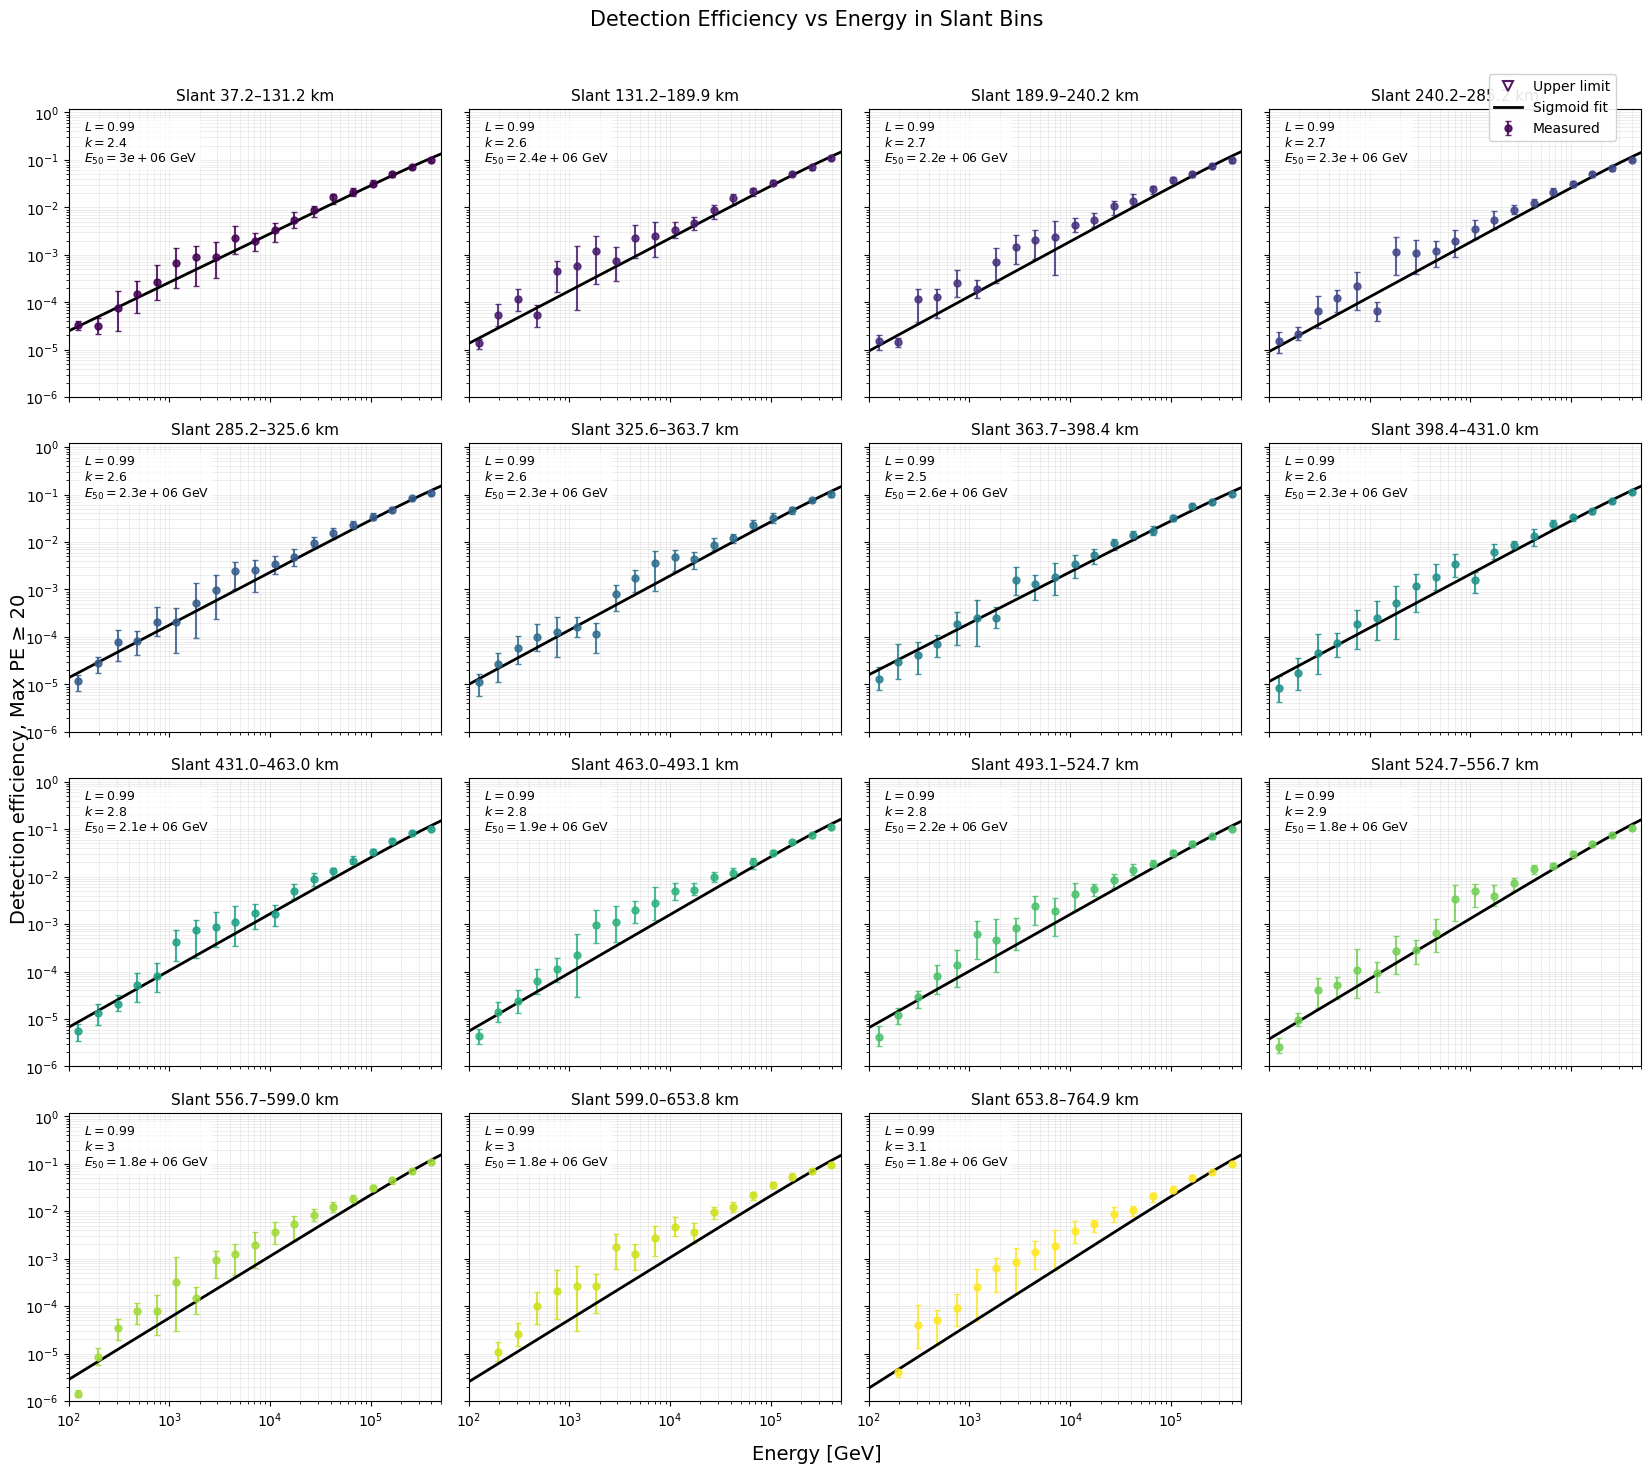

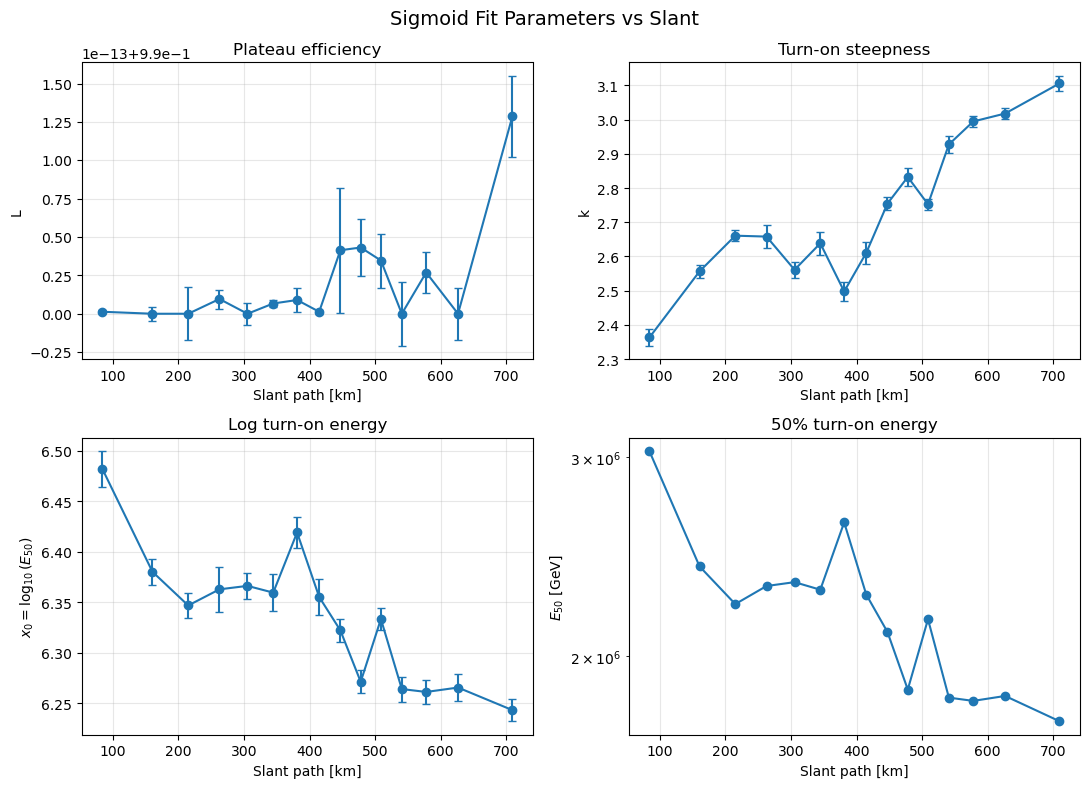

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize

# =============================================================================
# Settings
# =============================================================================
E_min = 1e2
E_max = 5e5
E_bins = np.logspace(np.log10((E_min)), np.log10((E_max)), 20)

num_slant_bins = 15
slant_bins = np.quantile(Slant[np.isfinite(Slant)], np.linspace(0, 1, num_slant_bins + 1))
slant_centres = 0.5 * (slant_bins[:-1] + slant_bins[1:])

print("Slant bins:", slant_bins)

PE_THRESHOLD    = 20 #1.5e5 #20
N_BOOTSTRAP     = 50
N_FIT_BOOTSTRAP = 20
CI_LEVEL        = 0.99

UPPER_LIMIT_CL = 0.5
UPPER_LIMIT_MU = -np.log(1 - UPPER_LIMIT_CL)
UL_SIGMA       = 0.01
trigger_data = optical_efficiency(photon_count, np.zeros(len(photon_count)))
rng = np.random.default_rng(seed=420)

# =============================================================================
# Sigmoid model
# =============================================================================
def sigmoid_model(logE, L, k, x0):
    z = -k * (logE - x0)
    z = np.clip(z, -500, 500)
    return L / (1.0 + np.exp(z))


def chi2(params, x_fit, y_fit, sigma_y):
    L, k, x0 = params
    y_pred = sigmoid_model(x_fit, L, k, x0)
    return np.sum(((y_pred - y_fit) / sigma_y) ** 2)


# =============================================================================
# Storage
# =============================================================================
efficiency_dict = {}
upper_limit_dict = {}
err_lo_dict = {}
err_hi_dict = {}
total_counts_dict = {}
passed_counts_dict = {}
fit_params_dict = {}
fit_unc_dict = {}
boot_eff_dict = {}

E_centres = np.sqrt(E_bins[:-1] * E_bins[1:])
logE_centres = np.log10(E_centres)

# =============================================================================
# Loop over slant bins
# =============================================================================
for s_idx in range(len(slant_bins) - 1):

    s_lo, s_hi = slant_bins[s_idx], slant_bins[s_idx + 1]

    mask = (
        np.isfinite(Energy_GeV) &
        np.isfinite(trigger_data) &
        np.isfinite(Slant) &
        (Energy_GeV > 0) &
        (Slant >= s_lo) &
        (Slant < s_hi)
    )

    E = Energy_GeV[mask]
    passed = trigger_data[mask]  

    n_events = len(E)

    if n_events == 0:
        print(f"No events in slant bin {s_idx}: [{s_lo:.2f}, {s_hi:.2f}] km")
        continue

    # -------------------------------------------------------------------------
    # Counts vs energy
    # -------------------------------------------------------------------------
    total_counts, _ = np.histogram(E, bins=E_bins)
    passed_counts, _ = np.histogram(E, bins=E_bins, weights=passed)

    efficiency = np.full(len(E_centres), np.nan)
    is_upper_limit = np.zeros(len(E_centres), dtype=bool)

    for i in range(len(E_centres)):
        n_tot = total_counts[i]
        n_pass = passed_counts[i]

        if n_tot == 0:
            efficiency[i] = np.nan
            is_upper_limit[i] = False

        elif n_pass == 0:
            efficiency[i] = UPPER_LIMIT_MU / n_tot
            is_upper_limit[i] = True

        else:
            efficiency[i] = n_pass / n_tot
            is_upper_limit[i] = False

    # -------------------------------------------------------------------------
    # Bootstrap efficiency uncertainty
    # -------------------------------------------------------------------------
    boot_eff = np.full((N_BOOTSTRAP, len(E_centres)), np.nan)

    for b in range(N_BOOTSTRAP):
        idx = rng.integers(0, n_events, size=n_events)

        E_b = E[idx]
        passed_b = passed[idx]

        total_b, _ = np.histogram(E_b, bins=E_bins)
        passed_b_counts, _ = np.histogram(E_b, bins=E_bins, weights=passed_b)

        with np.errstate(divide='ignore', invalid='ignore'):
            boot_eff[b] = np.where(total_b > 0, passed_b_counts / total_b, np.nan)

    alpha = (1 - CI_LEVEL) / 2

    ci_lo = np.nanpercentile(boot_eff, alpha * 100, axis=0)
    ci_hi = np.nanpercentile(boot_eff, (1 - alpha) * 100, axis=0)

    err_lo = efficiency - ci_lo
    err_hi = ci_hi - efficiency

    err_lo = np.where(~is_upper_limit, err_lo, np.nan)
    err_hi = np.where(~is_upper_limit, err_hi, np.nan)

    # -------------------------------------------------------------------------
    # Fit sigmoid for this slant bin
    # -------------------------------------------------------------------------
    measured_mask = (
        ~is_upper_limit &
        np.isfinite(efficiency) &
        (efficiency > 0)
    )

    ul_mask = (
        is_upper_limit &
        np.isfinite(efficiency) &
        (efficiency > 0)
    )

    fit_mask = measured_mask | ul_mask

    if fit_mask.sum() < 3:
        print(f"Not enough valid energy bins to fit slant bin {s_idx}")
        continue

    x_fit = logE_centres[fit_mask]
    y_fit = efficiency[fit_mask]

    sigma_y = np.empty_like(y_fit)

    meas_sub = measured_mask[fit_mask]
    ul_sub = ul_mask[fit_mask]

    sigma_meas = 0.5 * (
        np.clip(err_lo[fit_mask], 1e-6, None) +
        np.clip(err_hi[fit_mask], 1e-6, None)
    )

    sigma_y[meas_sub] = sigma_meas[meas_sub]
    sigma_y[ul_sub] = UL_SIGMA

    L0 = min(max(np.nanmax(y_fit), 1e-3), 1.0)
    half = 0.5 * L0

    above_half = y_fit >= half
    x00 = x_fit[np.argmax(above_half)] if above_half.any() else np.mean(x_fit)

    p0 = np.array([L0, 3.0, x00])

    bounds = [
        (0.99, 1.0),                                   # L
        (0.01, 10.0),                                   # k
        (logE_centres.min() - 10, logE_centres.max() + 10) # x0
    ]

    res = minimize(
        chi2,
        p0,
        args=(x_fit, y_fit, sigma_y),
        method='SLSQP',
        bounds=bounds,
        options={'maxiter': 500, 'ftol': 1e-8}
    )

    if not res.success:
        print(f"Warning: fit failed for slant bin {s_idx}")
        print(res.message)
        continue

    L_fit, k_fit, x0_fit = res.x

    chi2_val = chi2(res.x, x_fit, y_fit, sigma_y)
    dof = max(len(y_fit) - 3, 1)
    red_chi2 = chi2_val / dof
    p_value = 1.0 - stats.chi2.cdf(chi2_val, dof)

    # -------------------------------------------------------------------------
    # Bootstrap fit parameter uncertainty
    # -------------------------------------------------------------------------
    boot_params = np.full((N_FIT_BOOTSTRAP, 3), np.nan)

    for b in range(N_FIT_BOOTSTRAP):

        b_idx = b % N_BOOTSTRAP
        eff_b = boot_eff[b_idx].copy()

        # keep upper-limit values fixed
        eff_b = np.where(is_upper_limit, efficiency, eff_b)

        measured_mask_b = (
            ~is_upper_limit &
            np.isfinite(eff_b) &
            (eff_b > 0)
        )

        ul_mask_b = (
            is_upper_limit &
            np.isfinite(eff_b) &
            (eff_b > 0)
        )

        fit_mask_b = measured_mask_b | ul_mask_b

        if fit_mask_b.sum() < 3:
            continue

        x_fit_b = logE_centres[fit_mask_b]
        y_fit_b = eff_b[fit_mask_b]

        sigma_y_b = np.empty_like(y_fit_b)

        meas_sub_b = measured_mask_b[fit_mask_b]
        ul_sub_b = ul_mask_b[fit_mask_b]

        sigma_meas_b = 0.5 * (
            np.clip(err_lo[fit_mask_b], 1e-6, None) +
            np.clip(err_hi[fit_mask_b], 1e-6, None)
        )

        sigma_y_b[meas_sub_b] = sigma_meas_b[meas_sub_b]
        sigma_y_b[ul_sub_b] = UL_SIGMA

        try:
            res_b = minimize(
                chi2,
                res.x,
                args=(x_fit_b, y_fit_b, sigma_y_b),
                method='SLSQP',
                bounds=bounds,
                options={'maxiter': 500, 'ftol': 1e-8}
            )

            if res_b.success:
                boot_params[b] = res_b.x

        except Exception:
            pass

    param_std = np.nanstd(boot_params, axis=0)

    # -------------------------------------------------------------------------
    # Store results
    # -------------------------------------------------------------------------
    efficiency_dict[s_idx] = efficiency
    upper_limit_dict[s_idx] = is_upper_limit
    err_lo_dict[s_idx] = err_lo
    err_hi_dict[s_idx] = err_hi
    total_counts_dict[s_idx] = total_counts
    passed_counts_dict[s_idx] = passed_counts
    fit_params_dict[s_idx] = {
        "L": L_fit,
        "k": k_fit,
        "x0": x0_fit,
        "E50": 10**x0_fit,
        "chi2": chi2_val,
        "dof": dof,
        "red_chi2": red_chi2,
        "p_value": p_value
    }
    fit_unc_dict[s_idx] = {
        "L_err": param_std[0],
        "k_err": param_std[1],
        "x0_err": param_std[2]
    }
    boot_eff_dict[s_idx] = boot_eff

    print(
        f"\nSlant bin {s_idx}: [{s_lo:.2f}, {s_hi:.2f}] km"
        f"\n  L    = {L_fit:.4g} ± {param_std[0]:.3g}"
        f"\n  k    = {k_fit:.4g} ± {param_std[1]:.3g}"
        f"\n  x0   = {x0_fit:.4g} ± {param_std[2]:.3g}"
        f"\n  E50  = {10**x0_fit:.4g} GeV"
        f"\n  chi2/dof = {chi2_val:.2f}/{dof} = {red_chi2:.2f}"
    )
# =============================================================================
# N x N subplot: efficiency vs energy for each slant bin
# =============================================================================

import math

E_plot = np.logspace(np.log10(E_bins[0]), np.log10(E_bins[-1]), 500)
logE_plot = np.log10(E_plot)

valid_s = sorted(fit_params_dict.keys())
n_panels = len(valid_s)

ncols = math.ceil(np.sqrt(n_panels))
nrows = math.ceil(n_panels / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.2 * ncols, 3.6 * nrows),
    sharex=True,
    sharey=True
)

axes = np.atleast_1d(axes).ravel()

colors = plt.cm.viridis(np.linspace(0, 1, len(slant_bins) - 1))

# Common axis limits
xlim = (E_bins[0], E_bins[-1])

# For log-y, avoid zero
all_eff = []

for s_idx in valid_s:
    eff = efficiency_dict[s_idx]
    mask_eff = np.isfinite(eff) & (eff > 0)
    all_eff.extend(eff[mask_eff])

if len(all_eff) > 0:
    ymin = max(np.nanmin(all_eff) * 0.5, 1e-6)
else:
    ymin = 1e-6

ylim = (ymin, 1.2)

for panel_idx, s_idx in enumerate(valid_s):

    ax = axes[panel_idx]
    color = colors[s_idx]

    s_lo, s_hi = slant_bins[s_idx], slant_bins[s_idx + 1]

    efficiency = efficiency_dict[s_idx]
    is_upper_limit = upper_limit_dict[s_idx]
    err_lo = err_lo_dict[s_idx]
    err_hi = err_hi_dict[s_idx]

    measured_mask = (
        ~is_upper_limit &
        np.isfinite(efficiency) &
        (efficiency > 0)
    )

    ul_mask = (
        is_upper_limit &
        np.isfinite(efficiency) &
        (efficiency > 0)
    )

    # -------------------------------------------------------------------------
    # Data points
    # -------------------------------------------------------------------------
    ax.errorbar(
        E_centres[measured_mask],
        efficiency[measured_mask],
        yerr=[
            np.clip(err_lo[measured_mask], 0, None),
            np.clip(err_hi[measured_mask], 0, None)
        ],
        fmt='o',
        color=color,
        markersize=5,
        capsize=2,
        alpha=0.85,
        label='Measured'
    )

    # -------------------------------------------------------------------------
    # Upper limits
    # -------------------------------------------------------------------------
    ax.plot(
        E_centres[ul_mask],
        efficiency[ul_mask],
        marker='v',
        linestyle='none',
        color=color,
        markerfacecolor='none',
        markeredgewidth=1.5,
        markersize=7,
        alpha=0.9,
        label='Upper limit'
    )

    # Optional downward arrows for upper limits
    for xs, ys in zip(E_centres[ul_mask], efficiency[ul_mask]):
        if np.isfinite(ys) and ys > 0:
            ax.annotate(
                '',
                xy=(xs, ys * 0.6),
                xytext=(xs, ys),
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=color,
                    lw=1.1
                )
            )

    # -------------------------------------------------------------------------
    # Fit curve
    # -------------------------------------------------------------------------
    L = fit_params_dict[s_idx]["L"]
    k = fit_params_dict[s_idx]["k"]
    x0 = fit_params_dict[s_idx]["x0"]

    eff_fit = sigmoid_model(logE_plot, L, k, x0)

    ax.plot(
        E_plot,
        eff_fit,
        '-',
        color='black',
        linewidth=2,
        label='Sigmoid fit'
    )

    # -------------------------------------------------------------------------
    # Panel formatting
    # -------------------------------------------------------------------------
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.grid(True, which='both', alpha=0.3, linewidth=0.5)

    ax.set_title(
        f"Slant {s_lo:.1f}–{s_hi:.1f} km",
        fontsize=11
    )

    ax.text(
        0.04,
        0.96,
        rf"$L={L:.2g}$" + "\n" +
        rf"$k={k:.2g}$" + "\n" +
        rf"$E_{{50}}={10**x0:.2g}$ GeV",
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.75,
            edgecolor='none'
        )
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].axis('off')

# Shared labels
fig.supxlabel("Energy [GeV]", fontsize=14)
fig.supylabel(f"Detection efficiency, Max PE ≥ {PE_THRESHOLD}", fontsize=14)

fig.suptitle(
    "Detection Efficiency vs Energy in Slant Bins",
    fontsize=15,
    y=1.02
)

# One common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),
    fontsize=10,
    framealpha=0.9
)

plt.tight_layout()
plt.show()
# =============================================================================
# Plot fitted coefficients vs slant
# =============================================================================

valid_s = sorted(fit_params_dict.keys())

s_centres = np.array([slant_centres[i] for i in valid_s])

L_vals  = np.array([fit_params_dict[i]["L"] for i in valid_s])
k_vals  = np.array([fit_params_dict[i]["k"] for i in valid_s])
x0_vals = np.array([fit_params_dict[i]["x0"] for i in valid_s])
E50_vals = np.array([fit_params_dict[i]["E50"] for i in valid_s])

L_err  = np.array([fit_unc_dict[i]["L_err"] for i in valid_s])
k_err  = np.array([fit_unc_dict[i]["k_err"] for i in valid_s])
x0_err = np.array([fit_unc_dict[i]["x0_err"] for i in valid_s])

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes = axes.ravel()

axes[0].errorbar(s_centres, L_vals, yerr=L_err, fmt='o-', capsize=3)
axes[0].set_ylabel("L")
axes[0].set_title("Plateau efficiency")

axes[1].errorbar(s_centres, k_vals, yerr=k_err, fmt='o-', capsize=3)
axes[1].set_ylabel("k")
axes[1].set_title("Turn-on steepness")

axes[2].errorbar(s_centres, x0_vals, yerr=x0_err, fmt='o-', capsize=3)
axes[2].set_ylabel(r"$x_0 = \log_{10}(E_{50})$")
axes[2].set_title("Log turn-on energy")

axes[3].plot(s_centres, E50_vals, 'o-')
axes[3].set_yscale('log')
axes[3].set_ylabel(r"$E_{50}$ [GeV]")
axes[3].set_title("50% turn-on energy")

for ax in axes:
    ax.set_xlabel("Slant path [km]")
    ax.grid(True, alpha=0.3)

plt.suptitle("Sigmoid Fit Parameters vs Slant", fontsize=14)
plt.tight_layout()
plt.show()


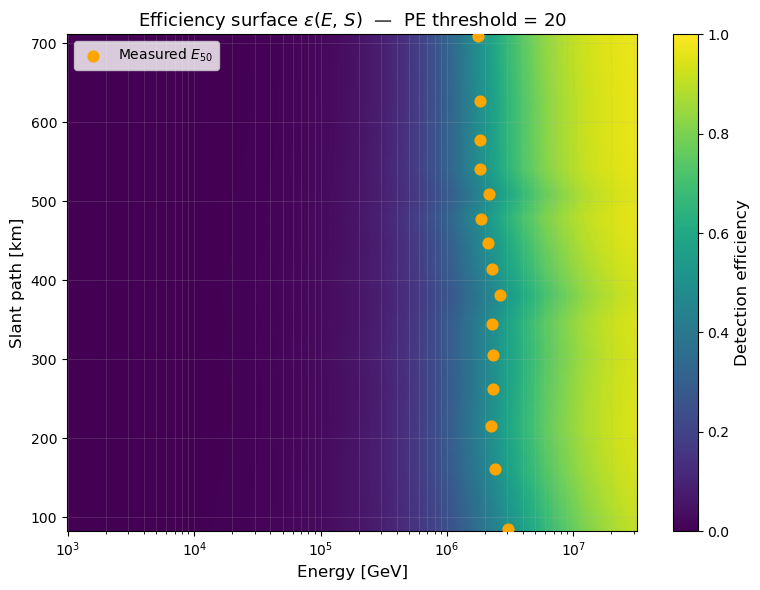

Efficiency profile (extended range):
  S [km]    E(ε≥10%) [GeV]    E(ε≥50%) [GeV]     ε_max
--------------------------------------------------------
      84          3.62e+05           3.1e+06    0.9081
     161          3.38e+05          2.52e+06    0.9364
     215          3.38e+05          2.27e+06    0.9459
     263           3.5e+05          2.35e+06    0.9440
     305          3.38e+05          2.43e+06    0.9387
     345           3.5e+05          2.35e+06    0.9433
     381           3.5e+05           2.7e+06    0.9284
     415          3.38e+05          2.35e+06    0.9425
     447          3.38e+05          2.19e+06    0.9528
     478          3.26e+05          1.91e+06    0.9602
     509           3.5e+05          2.19e+06    0.9522
     541          3.38e+05          1.91e+06    0.9639
     578           3.5e+05          1.91e+06    0.9663
     626           3.5e+05          1.91e+06    0.9667
     709           3.5e+05          1.78e+06    0.9704


In [10]:
# =============================================================================
# 2D Interpolation of efficiency over (Energy, Slant)
# =============================================================================
from scipy.interpolate import RegularGridInterpolator, interp1d

# -----------------------------------------------------------------------------
# Step 1: build a dense (log-E, slant) grid of sigmoid-evaluated efficiency
# -----------------------------------------------------------------------------

valid_s   = sorted(fit_params_dict.keys())
s_centres = np.array([slant_centres[i] for i in valid_s])

logE_grid = np.linspace(3.0, 7.5, 300)
E_grid    = 10**logE_grid

L_vals  = np.array([fit_params_dict[i]["L"]  for i in valid_s])
k_vals  = np.array([fit_params_dict[i]["k"]  for i in valid_s])
x0_vals = np.array([fit_params_dict[i]["x0"] for i in valid_s])

L_interp  = interp1d(s_centres, L_vals,  kind='linear',
                     bounds_error=False, fill_value=(L_vals[0],  L_vals[-1]))
k_interp  = interp1d(s_centres, k_vals,  kind='linear',
                     bounds_error=False, fill_value=(k_vals[0],  k_vals[-1]))
x0_interp = interp1d(s_centres, x0_vals, kind='linear',
                     bounds_error=False, fill_value=(x0_vals[0], x0_vals[-1]))

# Add small padding so boundary centres are interior points
s_grid = np.linspace(s_centres[0] - 1e-6, s_centres[-1] + 1e-6, 150)

# Rebuild the 2D mesh
logE_mesh, s_mesh = np.meshgrid(logE_grid, s_grid)

L_mesh  = L_interp(s_mesh)
k_mesh  = k_interp(s_mesh)
x0_mesh = x0_interp(s_mesh)

z_mesh      = np.clip(-k_mesh * (logE_mesh - x0_mesh), -500, 500)
eff_grid_2d = L_mesh / (1.0 + np.exp(z_mesh))

# Rebuild interpolator
eff_interpolator = RegularGridInterpolator(
    (s_grid, logE_grid),
    eff_grid_2d,
    method='linear',
    bounds_error=False,
    fill_value=np.nan
)

def detection_efficiency(E_GeV, slant_km):
    E_GeV    = np.asarray(E_GeV,    dtype=float)
    slant_km = np.asarray(slant_km, dtype=float)
    pts = np.column_stack([slant_km.ravel(), np.log10(E_GeV.ravel())])
    eff = eff_interpolator(pts)
    return eff.reshape(E_GeV.shape)

# =============================================================================
# Heat map
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.pcolormesh(
    E_grid, s_grid, eff_grid_2d,
    shading='auto',
    cmap='viridis',
    vmin=0, vmax=1
)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Detection efficiency', fontsize=12)


E50_vals = 10**x0_vals
ax.scatter(
    E50_vals, s_centres,
    c='orange', s=60, zorder=5,
    label=r'Measured $E_{50}$'
)

ax.set_xscale('log')
ax.set_xlabel('Energy [GeV]',    fontsize=12)
ax.set_ylabel('Slant path [km]', fontsize=12)
ax.set_title(
    rf'Efficiency surface $\varepsilon(E,\,S)$  —  PE threshold = {PE_THRESHOLD}',
    fontsize=13
)
ax.legend(fontsize=10, loc='upper left')   # explicit loc avoids slow search
ax.grid(True, which='both', alpha=0.25, linewidth=0.5)
plt.tight_layout()
plt.show()

# =============================================================================
# Verify: no more NaNs
# =============================================================================
print("Efficiency profile (extended range):")
print(f"{'S [km]':>8}  {'E(ε≥10%) [GeV]':>16}  {'E(ε≥50%) [GeV]':>16}  {'ε_max':>8}")
print("-" * 56)
for s in s_centres:
    eff_slice = detection_efficiency(E_grid, np.full_like(E_grid, s))
    above_10  = E_grid[eff_slice >= 0.10]
    above_50  = E_grid[eff_slice >= 0.50]
    E_10  = above_10[0]          if len(above_10) > 0 else float('nan')
    E_50  = above_50[0]          if len(above_50) > 0 else float('nan')
    emax  = np.nanmax(eff_slice) if np.any(~np.isnan(eff_slice)) else float('nan')
    print(f"{s:>8.0f}  {E_10:>16.3g}  {E_50:>16.3g}  {emax:>8.4f}")